Using sheet: 'Probe Frequency Domain'
Available columns before renaming: ['Probe', 'Time', 'Frequency (Hz)', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Real Impedance Re{z}(Ω)', 'Negative Imaginary Impedance -Im{z}(Ω)']
Available columns after renaming: ['Probe', 'time', 'frequency', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Z_real', 'Z_imag_neg']


Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 75/75 [00:06<00:00, 11.03it/s]


TSFRESH features saved to 'ecm_features.xlsx'.
Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'
   sweep_id                time  RelTime_hr      model_name      RMSE  \
0         1 2024-07-30 10:12:08    0.078333  Advanced_2RCPE  0.003102   
1         2 2024-07-30 10:16:50    0.156667  Advanced_2RCPE  0.000943   
2         3 2024-07-30 10:21:34    0.235556  Advanced_2RCPE  0.002043   
3         4 2024-07-30 10:26:16    0.313889  Advanced_2RCPE  0.000925   
4         5 2024-07-30 10:30:59    0.392500  Advanced_2RCPE  0.000969   

           AIC          BIC  rel_error_percent  \
0 -1449.332705 -1421.457787           5.005587   
1 -1735.138415 -1707.263498           1.663487   
2 -1549.565608 -1521.690691           3.618548   
3 -1739.762860 -1711.887942           1.645090   
4 -1728.506306 -1700.631388           1.728998   

                                         param_names  \
0  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...   
1  [L0, R0, R1, L1, R2, CPE1-Q, CPE1

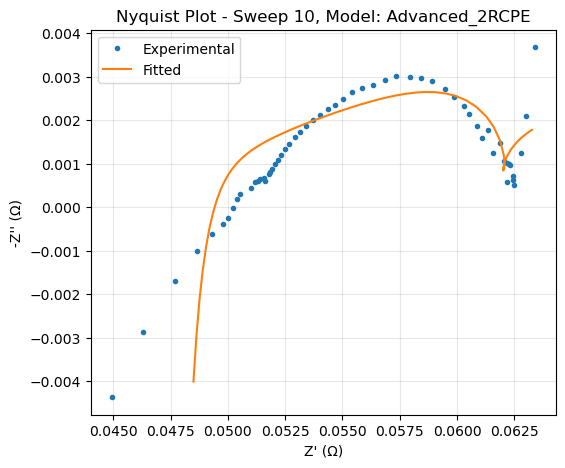

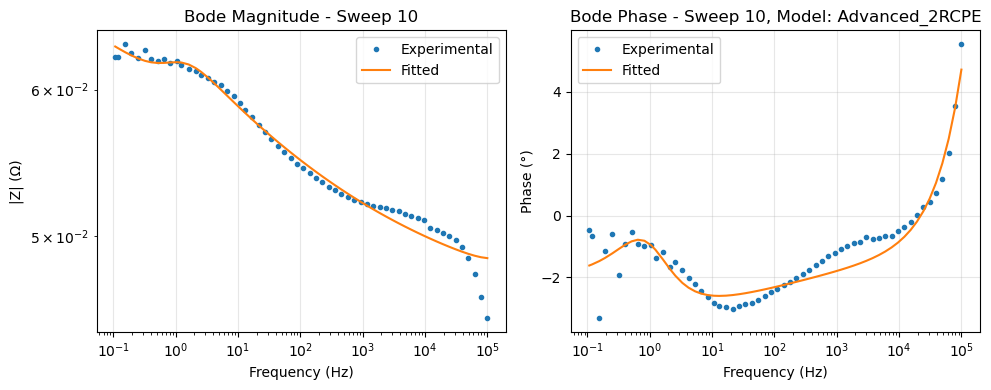


Merged features shape: (74, 793)
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best XGB Model: {'regressor__estimator__learning_rate': 0.01, 'regressor__estimator__max_depth': 10, 'regressor__estimator__n_estimators': 100}
Test RMSE (Parameters): 306958.6241


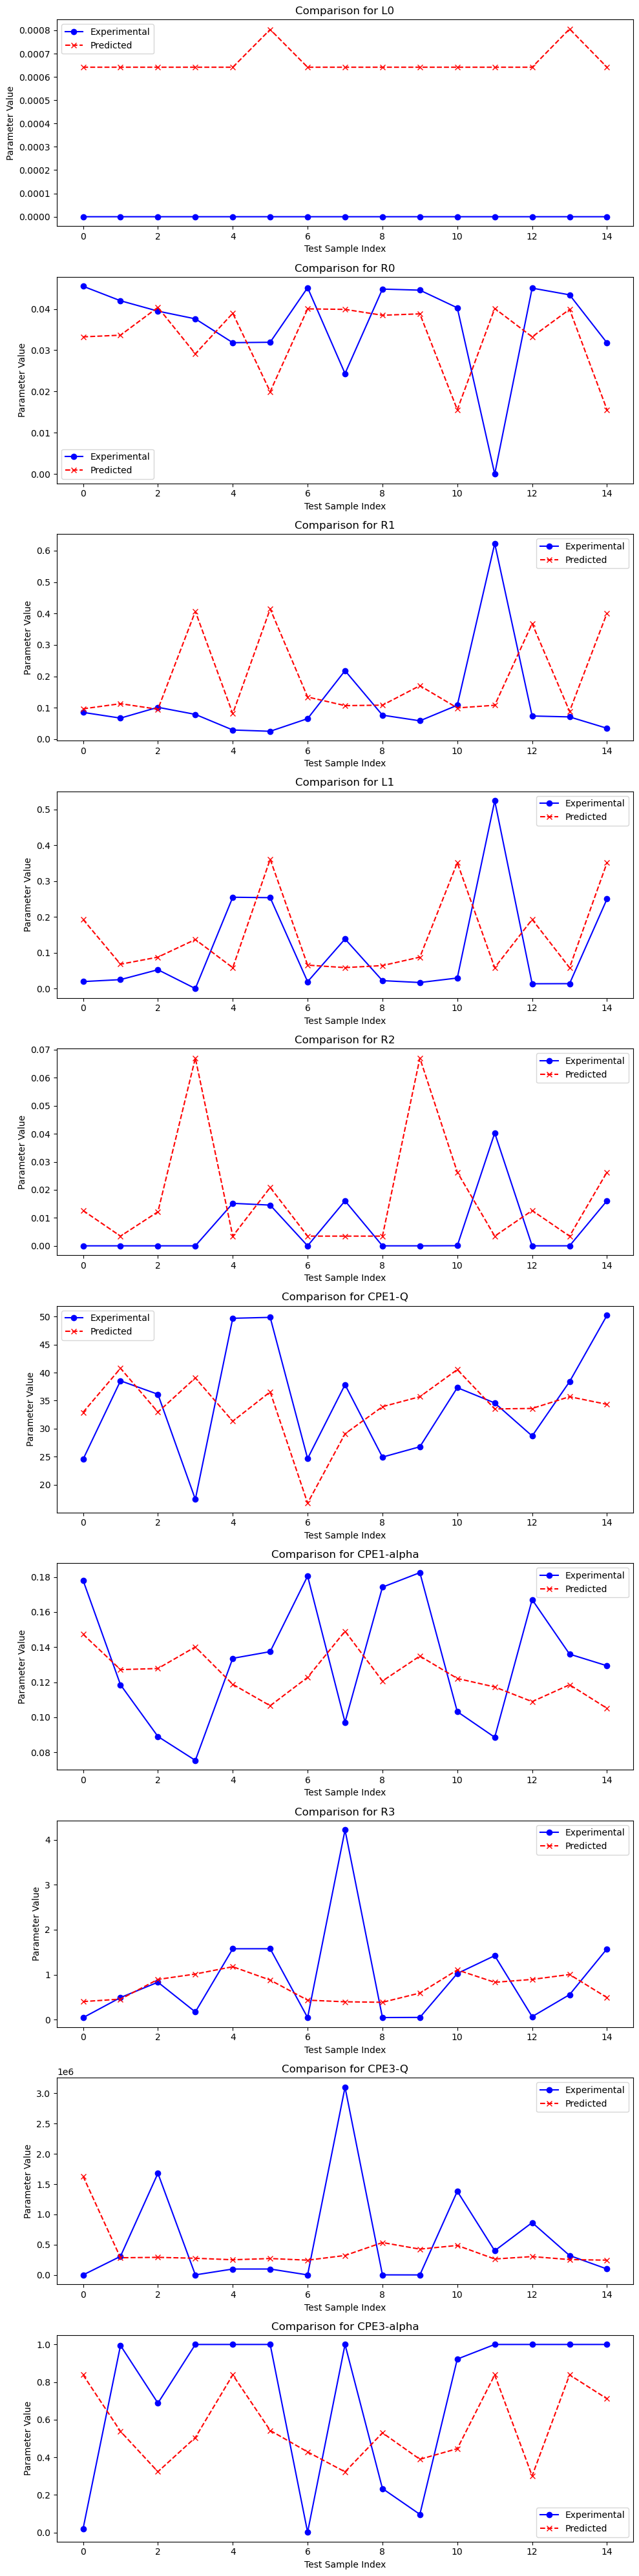

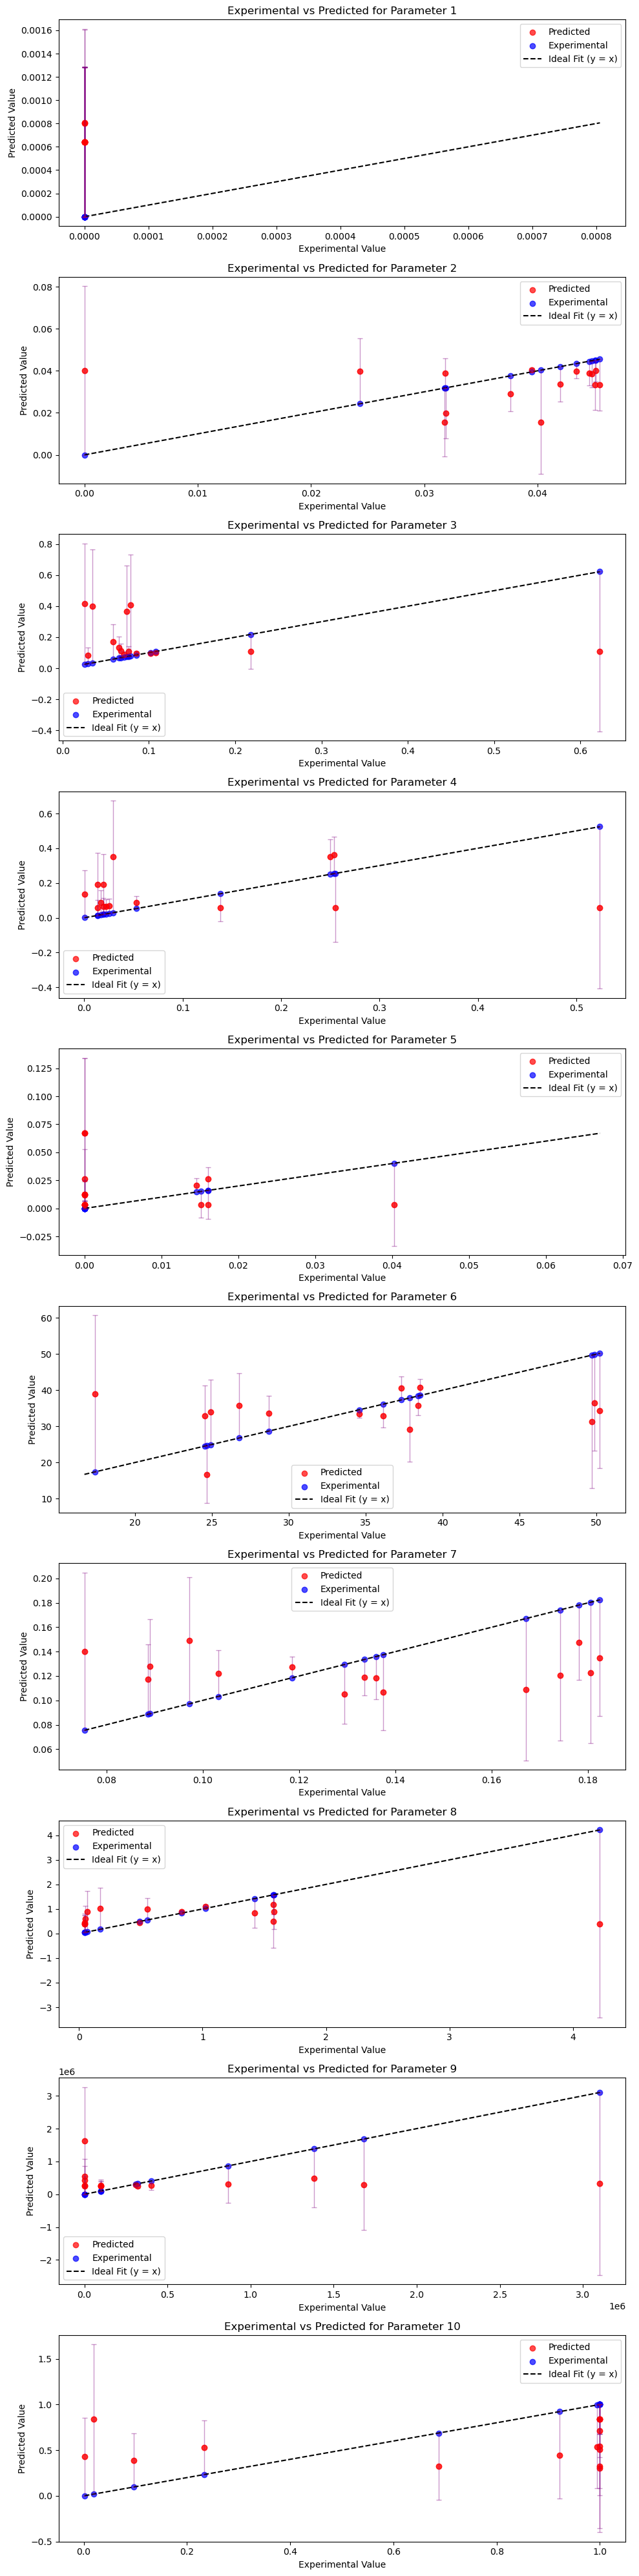

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from pathlib import Path

from impedance.models.circuits import CustomCircuit
from impedance import preprocessing

from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
import xgboost as xgb

warnings.filterwarnings("ignore")

###############################################################################
# 1. DATA LOADING: MULTI-SHEET EXCEL (6300.xls)
###############################################################################
file_path = "6300.xls"  # Path to your Excel file

# Read all sheets into a dictionary
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Prefer the "Probe Frequency Domain" sheet if available
if "Probe Frequency Domain" in all_sheets and not all_sheets["Probe Frequency Domain"].empty:
    df_eis = all_sheets["Probe Frequency Domain"]
    print("Using sheet: 'Probe Frequency Domain'")
elif "EIS_Data" in all_sheets and not all_sheets["EIS_Data"].empty:
    df_eis = all_sheets["EIS_Data"]
    print("Using sheet: 'EIS_Data'")
else:
    for sheet_name, sheet_df in all_sheets.items():
        if not sheet_df.empty:
            df_eis = sheet_df
            print(f"Neither 'Probe Frequency Domain' nor 'EIS_Data' found; using sheet: '{sheet_name}' instead.")
            break
    else:
        raise ValueError("No nonempty sheet found in 6300.xls.")

df_fitted_params = all_sheets.get("Fitted_Parameters", pd.DataFrame())

###############################################################################
# 2. DATA CLEANUP & TIME DERIVATION
###############################################################################
# Expected columns for frequency domain:
# "Probe", "Time", "Frequency (Hz)", "Voltage Magnitude |V(t)|(V)", "Current Magnitude |I(t)|(A)",
# "Voltage Phase ∠V (degree)", "Current Phase ∠I (degree)", "Impedance Magnitude |Z(f)|(Ω)",
# "Phase Difference (degree)", "Real Impedance Re{z}(Ω)", "Negative Imaginary Impedance -Im{z}(Ω)"

print("Available columns before renaming:", df_eis.columns.tolist())

rename_map = {
    "Frequency (Hz)": "frequency",
    "Real Impedance Re{z}(Ω)": "Z_real",
    "Negative Imaginary Impedance -Im{z}(Ω)": "Z_imag_neg",
    "Time": "time"
}
df_eis.rename(columns=rename_map, inplace=True)
print("Available columns after renaming:", df_eis.columns.tolist())

required_cols = ["frequency", "Z_real", "Z_imag_neg"]
missing = [col for col in required_cols if col not in df_eis.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}. Available columns: {df_eis.columns.tolist()}")

df_eis.dropna(subset=required_cols, inplace=True)

if "time" in df_eis.columns:
    df_eis["time"] = pd.to_datetime(df_eis["time"], errors="coerce")
    df_eis.dropna(subset=["time"], inplace=True)
    df_eis["RelTime_sec"] = (df_eis["time"] - df_eis["time"].min()).dt.total_seconds()
    df_eis["RelTime_hr"] = df_eis["RelTime_sec"] / 3600
else:
    df_eis["RelTime_hr"] = np.arange(len(df_eis)) * 0.1

df_eis["sweep_id"] = df_eis.groupby("time").ngroup() if "time" in df_eis.columns else 0

###############################################################################
# 3. AUTO-FEATURIZATION WITH TSFRESH (OPTIONAL)
###############################################################################
df_tsfresh = df_eis[["sweep_id", "frequency", "Z_real"]].rename(
    columns={"sweep_id": "id", "frequency": "time", "Z_real": "value"}
)
extracted_features = extract_features(df_tsfresh, column_id="id", column_sort="time", n_jobs=0)
extracted_features = impute(extracted_features)
extracted_features.reset_index(inplace=True)
extracted_features.rename(columns={"index": "sweep_id"}, inplace=True)
extracted_features.to_excel("ecm_features.xlsx", index=False)
print("TSFRESH features saved to 'ecm_features.xlsx'.")

###############################################################################
# 4. DEFINE ECM MODELS (SIMPLE & ADVANCED) WITH INITIAL GUESSES
###############################################################################
simple_model_info = {
    "name": "Simple_Randles",
    "circuit": "R0-p(R1,C1)",
    "initial_guess": [0.04911, 0.0086883, 0.45421],
    "param_names": ["R0", "R1", "C1"]
}

advanced_model_info = {
    "name": "Advanced_2RCPE",
    "circuit": "L0-R0-p(R1-L1, R2-CPE1, R3-CPE3)",
    "initial_guess": [
        0.0,       # L0
        0.04941,   # R0
        0.0083883, # R1
        2.0785,    # L1
        0.0083683, # R2
        0.46421,   # CPE1-Q
        1.0,       # CPE1-alpha
        2.2071,    # R3
        1.0,       # CPE3-Q
        1.0        # CPE3-alpha
    ],
    "param_names": ["L0", "R0", "R1", "L1", "R2", "CPE1-Q", "CPE1-alpha", "R3", "CPE3-Q", "CPE3-alpha"]
}

model_candidates = [simple_model_info, advanced_model_info]

###############################################################################
# 5. ECM FITTING FUNCTION WITH RMSE, AIC, AND BIC, INCLUDING PHYSICAL CHECKS
###############################################################################
def fit_and_evaluate_model(model_dict, freq, Z_exp):
    circuit_str = model_dict["circuit"]
    init_guess = model_dict["initial_guess"]
    
    circuit_model = CustomCircuit(circuit=circuit_str, initial_guess=init_guess)
    circuit_model.fit(freq, Z_exp)
    
    Z_fit = circuit_model.predict(freq)
    residuals = Z_exp - Z_fit
    rmse = np.sqrt(np.mean(np.abs(residuals)**2))
    
    n = len(freq)
    k = len(circuit_model.parameters_)
    rss = np.sum(np.abs(residuals)**2)
    
    N_eff = 2 * n
    aic = 2 * k + N_eff * np.log(rss / N_eff + 1e-15)
    bic = np.log(N_eff) * k + N_eff * np.log(rss / N_eff + 1e-15)
    
    param_names = model_dict["param_names"]
    fitted_params = circuit_model.parameters_
    for name, value in zip(param_names, fitted_params):
        if (name.startswith('R') or name.startswith('L')) and value < 0:
            return None
    
    return {
        "model_name": model_dict["name"],
        "params": fitted_params,
        "param_names": param_names,
        "rmse": rmse,
        "aic": aic,
        "bic": bic
    }

###############################################################################
# 6. LOOP OVER SWEEPS AND SELECT THE BEST MODEL PER SWEEP
###############################################################################
error_threshold_percent = 10.0 
fit_results = []

for sweep_id, group in df_eis.groupby("sweep_id"):
    group = group.sort_values("frequency")
    if len(group) < 3:
        continue
    
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    if not np.all(np.isfinite(Z_exp)) or np.any(freq <= 0):
        continue
    
    best_fit = None
    for model_dict in model_candidates:
        try:
            result = fit_and_evaluate_model(model_dict, freq, Z_exp)
            if result is None:
                continue
            avg_imp = np.mean(np.abs(Z_exp))
            rel_error_percent = (result["rmse"] / avg_imp) * 100
            
            if rel_error_percent <= error_threshold_percent:
                if best_fit is None or (result["rmse"] < best_fit["rmse"] or result["aic"] < best_fit["aic"]):
                    best_fit = result
                    best_fit["rel_error_percent"] = rel_error_percent
        except Exception as e:
            print(f"Fitting failed for sweep {sweep_id} with model {model_dict['name']}: {e}")
    
    if best_fit is not None:
        time_val = group["time"].iloc[0] if "time" in group.columns else None
        rel_time_hr = group["RelTime_hr"].iloc[0] if "RelTime_hr" in group.columns else None
        fit_results.append({
            "sweep_id": sweep_id,
            "time": time_val,
            "RelTime_hr": rel_time_hr,
            "model_name": best_fit["model_name"],
            "RMSE": best_fit["rmse"],
            "AIC": best_fit["aic"],
            "BIC": best_fit["bic"],
            "rel_error_percent": best_fit["rel_error_percent"],
            "param_names": best_fit["param_names"],
            "params": best_fit["params"]
        })

fit_df = pd.DataFrame(fit_results)
if "RelTime_hr" in fit_df.columns and fit_df["RelTime_hr"].notnull().all():
    fit_df = fit_df.sort_values("RelTime_hr")
else:
    fit_df = fit_df.sort_values("sweep_id")

if fit_df.empty:
    raise RuntimeError("No valid ECM fits found for any sweep.")

fit_df.to_excel("ECM_fitting_results_advanced.xlsx", index=False)
print("Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'")
print(fit_df.head())

###############################################################################
# 7. VALIDATION PLOTS: NYQUIST AND BODE PLOTS FOR BEST FIT
###############################################################################
def plot_nyquist(freq, Z_exp, Z_fit, sweep_id, model_name):
    plt.figure(figsize=(6, 5))
    plt.plot(Z_exp.real, -Z_exp.imag, 'o', label='Experimental', markersize=3)
    plt.plot(Z_fit.real, -Z_fit.imag, '-', label='Fitted')
    plt.xlabel("Z' (Ω)")
    plt.ylabel("-Z'' (Ω)")
    plt.title(f'Nyquist Plot - Sweep {sweep_id}, Model: {model_name}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_bode(freq, Z_exp, Z_fit, sweep_id, model_name):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.loglog(freq, np.abs(Z_exp), 'o', label='Experimental', markersize=3)
    plt.loglog(freq, np.abs(Z_fit), '-', label='Fitted')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("|Z| (Ω)")
    plt.title(f'Bode Magnitude - Sweep {sweep_id}')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.semilogx(freq, np.angle(Z_exp, deg=True), 'o', label='Experimental', markersize=3)
    plt.semilogx(freq, np.angle(Z_fit, deg=True), '-', label='Fitted')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Phase (°)")
    plt.title(f'Bode Phase - Sweep {sweep_id}, Model: {model_name}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

best_idx = fit_df["RMSE"].idxmin()
best_sweep_id = fit_df.loc[best_idx, "sweep_id"]
best_model_name = fit_df.loc[best_idx, "model_name"]
best_params = fit_df.loc[best_idx, "params"]
print(f"\nBest overall fit: Sweep {best_sweep_id}, Model: {best_model_name}")

best_circuit = None
for m in model_candidates:
    if m["name"] == best_model_name:
        best_circuit = CustomCircuit(circuit=m["circuit"], initial_guess=m["initial_guess"])
        best_circuit.parameters_ = best_params
        break

best_group = df_eis[df_eis["sweep_id"] == best_sweep_id].sort_values("frequency")
freq_best = best_group["frequency"].values
Z_exp_best = best_group["Z_real"].values + 1j * (-best_group["Z_imag_neg"].values)
Z_fit_best = best_circuit.predict(freq_best)

plot_nyquist(freq_best, Z_exp_best, Z_fit_best, best_sweep_id, best_model_name)
plot_bode(freq_best, Z_exp_best, Z_fit_best, best_sweep_id, best_model_name)

###############################################################################
# 8. MERGE TSFRESH FEATURES WITH FITTED LABELS FOR ML TRAINING
###############################################################################
merged_df = pd.merge(extracted_features, fit_df, on="sweep_id", how="inner").dropna()
print(f"\nMerged features shape: {merged_df.shape}")

X = merged_df.drop(columns=["sweep_id", "time", "model_name", "RMSE", "AIC", "BIC", 
                              "rel_error_percent", "param_names", "params", "RelTime_hr"], errors="ignore").values

param_list = merged_df["params"].tolist()
max_len = max(len(p) for p in param_list)
Y = np.array([np.pad(p, (0, max_len - len(p)), constant_values=np.nan) for p in param_list])
Y = np.nan_to_num(Y)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

pipeline_xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", MultiOutputRegressor(xgb.XGBRegressor(random_state=42)))
])

param_grid = {
    "regressor__estimator__n_estimators": [100, 300, 500],
    "regressor__estimator__max_depth": [5, 10, 20],
    "regressor__estimator__learning_rate": [0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    pipeline_xgb,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nBest XGB Model: {grid_search.best_params_}")
print(f"Test RMSE (Parameters): {rmse_test:.4f}")

# --- NEW: Comparison Plot (Option B: Over Test Sample Indices) ---
n_params = Y.shape[1]
fig, axs = plt.subplots(n_params, 1, figsize=(10, 4 * n_params))
if n_params == 1:
    axs = [axs]
for i in range(n_params):
    sample_indices = np.arange(len(y_test[:, i]))
    axs[i].plot(sample_indices, y_test[:, i], 'bo-', label='Experimental')
    axs[i].plot(sample_indices, y_pred[:, i], 'rx--', label='Predicted')
    axs[i].set_xlabel("Test Sample Index")
    axs[i].set_ylabel("Parameter Value")
    # Get parameter label if available
    param_label = (merged_df['param_names'].iloc[0][i]
                   if 'param_names' in merged_df.columns and isinstance(merged_df['param_names'].iloc[0], (list, tuple))
                   else f"Parameter {i}")
    axs[i].set_title(f"Comparison for {param_label}")
    axs[i].legend()
plt.tight_layout()
plt.show()
n_params = Y.shape[1]
fig, axs = plt.subplots(n_params, 1, figsize=(10, 4 * n_params))
if n_params == 1:
    axs = [axs]

for i in range(n_params):
    # Scatter plot of Experimental vs Predicted
    axs[i].scatter(y_test[:, i], y_pred[:, i], color='red', label='Predicted', alpha=0.7)
    axs[i].scatter(y_test[:, i], y_test[:, i], color='blue', label='Experimental', alpha=0.7)
    
    # Plot ideal y = x line for reference
    min_val = min(np.min(y_test[:, i]), np.min(y_pred[:, i]))
    max_val = max(np.max(y_test[:, i]), np.max(y_pred[:, i]))
    axs[i].plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal Fit (y = x)')
    
    # Add error bars
    errors = np.abs(y_pred[:, i] - y_test[:, i])
    axs[i].errorbar(y_test[:, i], y_pred[:, i], yerr=errors, fmt='o', color='red', ecolor='purple', elinewidth=1, capsize=3, alpha=0.4)
    
    # Set axis labels and title
    axs[i].set_xlabel("Experimental Value")
    axs[i].set_ylabel("Predicted Value")
    param_label = f"Parameter {i+1}"  # Custom parameter label if needed
    axs[i].set_title(f"Experimental vs Predicted for {param_label}")
    axs[i].legend()

plt.tight_layout()
plt.show()

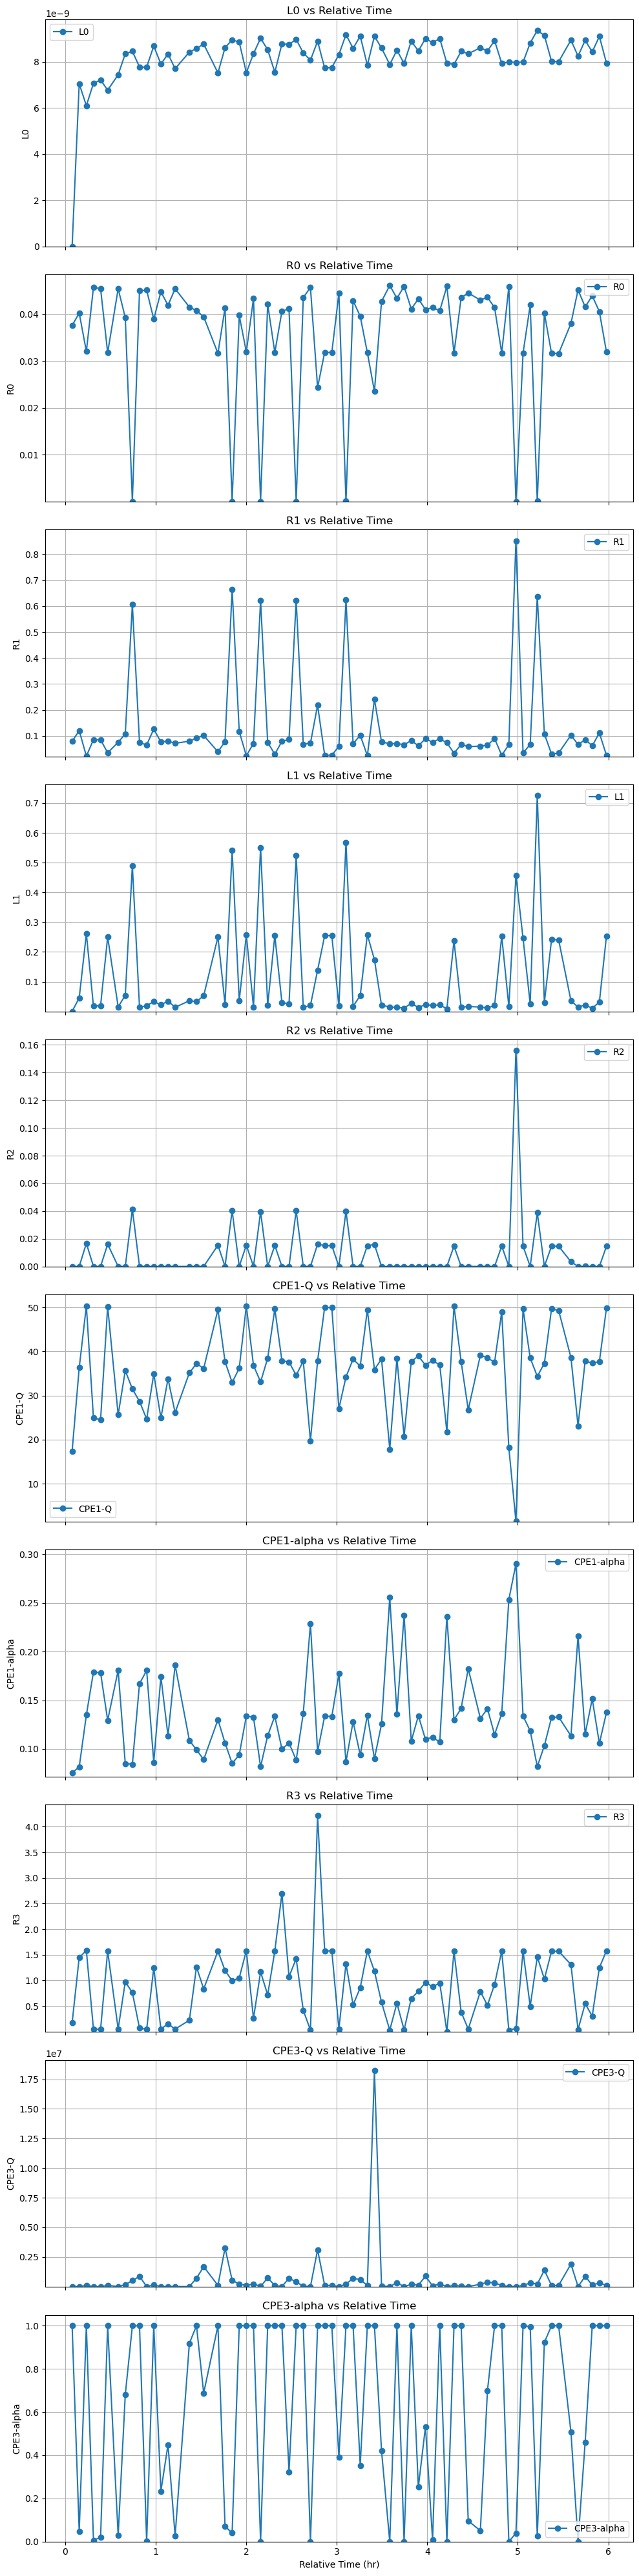

In [3]:
# Filter for advanced model fits (using "Advanced_2RCPE")
advanced_fit_df = fit_df[fit_df["model_name"] == "Advanced_2RCPE"].copy()

if advanced_fit_df.empty:
    print("No advanced model fits found in the results.")
else:
    # If RelTime_hr is not in fit_df, merge it from df_eis
    if "RelTime_hr" not in advanced_fit_df.columns:
        rel_time = df_eis.groupby("sweep_id")["RelTime_hr"].mean().reset_index()
        advanced_fit_df = pd.merge(advanced_fit_df, rel_time, on="sweep_id", how="left")
    
    # Get parameter names from advanced model info
    param_names = advanced_model_info["param_names"]
    
    # Create separate columns for each parameter from the 'params' list
    for i, pname in enumerate(param_names):
        advanced_fit_df[pname] = advanced_fit_df["params"].apply(lambda x: x[i] if len(x) > i else np.nan)
    
    n_params = len(param_names)
    fig, axs = plt.subplots(n_params, 1, figsize=(10, 4*n_params), sharex=True)
    if n_params == 1:
        axs = [axs]
    
    for i, pname in enumerate(param_names):
        axs[i].plot(advanced_fit_df["RelTime_hr"], advanced_fit_df[pname], 'o-', label=pname)
        axs[i].set_ylabel(pname)
        axs[i].set_title(f'{pname} vs Relative Time')
        axs[i].legend()
        axs[i].grid(True)
        # Set y-axis limits with a small margin
        y_min = advanced_fit_df[pname].min() * 0.95 if advanced_fit_df[pname].min() < 0 else advanced_fit_df[pname].min() * 0.95
        y_max = advanced_fit_df[pname].max() * 1.05
        axs[i].set_ylim(y_min, y_max)
    
    axs[-1].set_xlabel("Relative Time (hr)")
    plt.tight_layout()
    plt.show()

Using sheet: 'Probe Frequency Domain'
Available columns before renaming: ['Probe', 'Time', 'Frequency (Hz)', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Real Impedance Re{z}(Ω)', 'Negative Imaginary Impedance -Im{z}(Ω)']
Available columns after renaming: ['Probe', 'time', 'frequency', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Z_real', 'Z_imag_neg']


Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 75/75 [00:05<00:00, 12.99it/s]


TSFRESH features saved to 'ecm_features.xlsx'.
Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'
       model_name                                             params  \
0  Advanced_2RCPE  [5e-324, 0.03761107914520926, 0.07902309698904...   
1  Advanced_2RCPE  [7.045384613262934e-09, 0.04027785016605508, 0...   
2  Advanced_2RCPE  [6.0967988626392084e-09, 0.032068462567683656,...   
3  Advanced_2RCPE  [7.057724824939383e-09, 0.04573823685960637, 0...   
4  Advanced_2RCPE  [7.210451107219214e-09, 0.04551139213412436, 0...   

                                         param_names      rmse          aic  \
0  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.003102 -1449.332705   
1  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000943 -1735.138415   
2  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.002043 -1549.565608   
3  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000925 -1739.762860   
4  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.0009

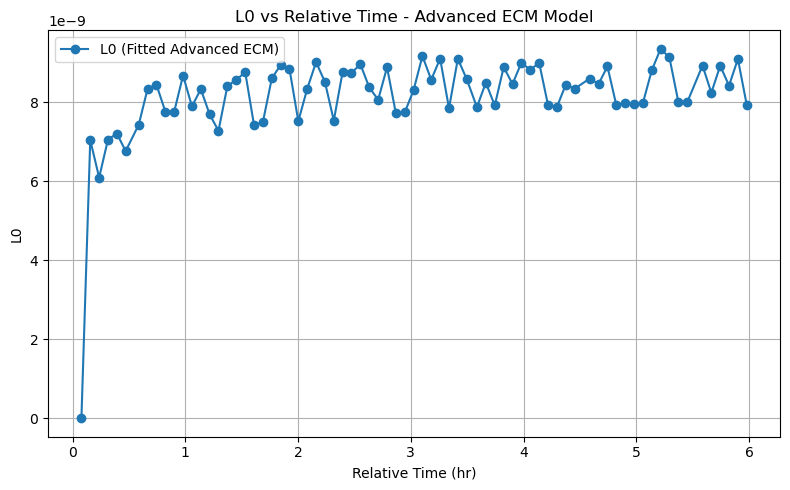

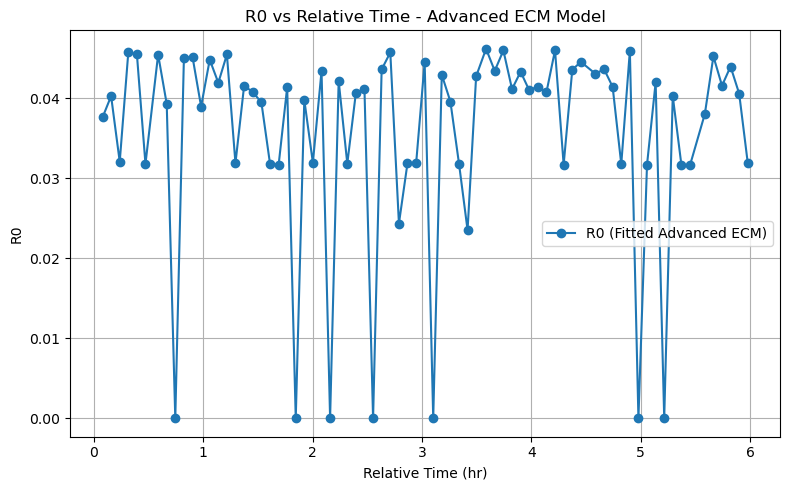

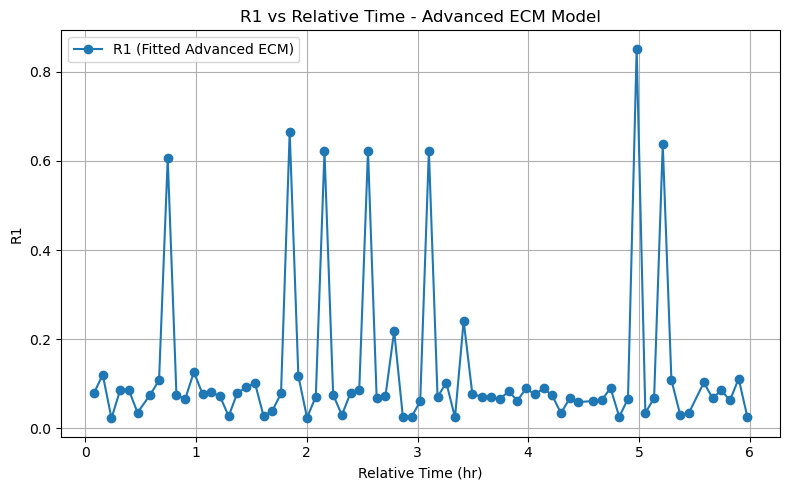

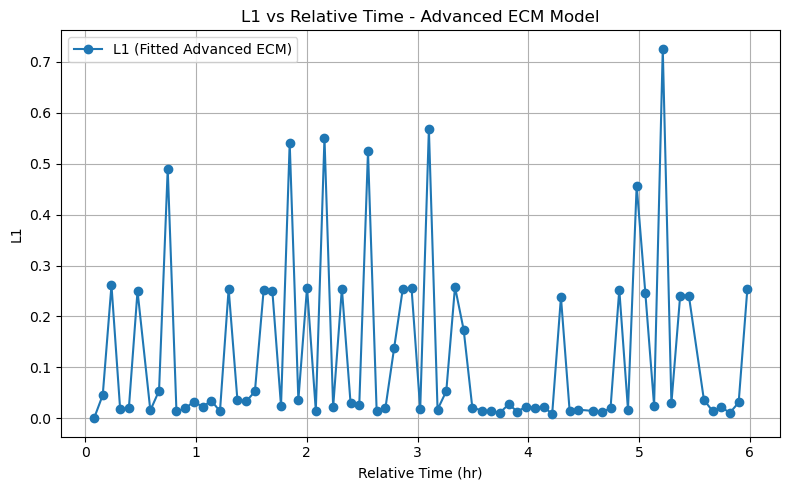

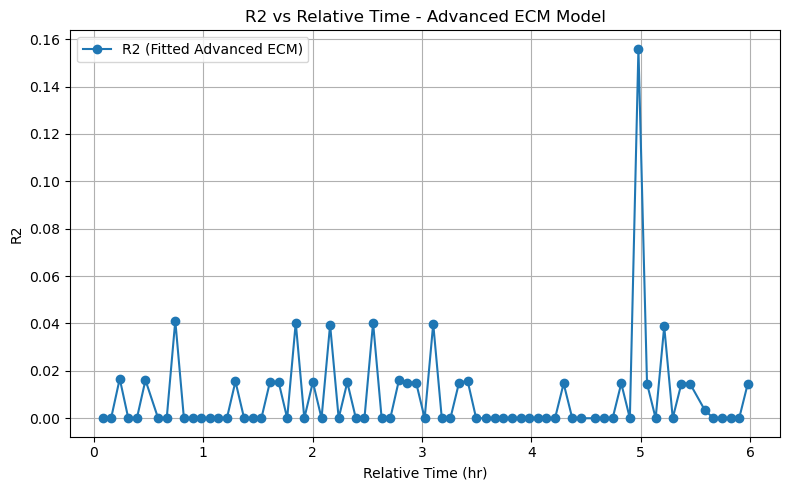

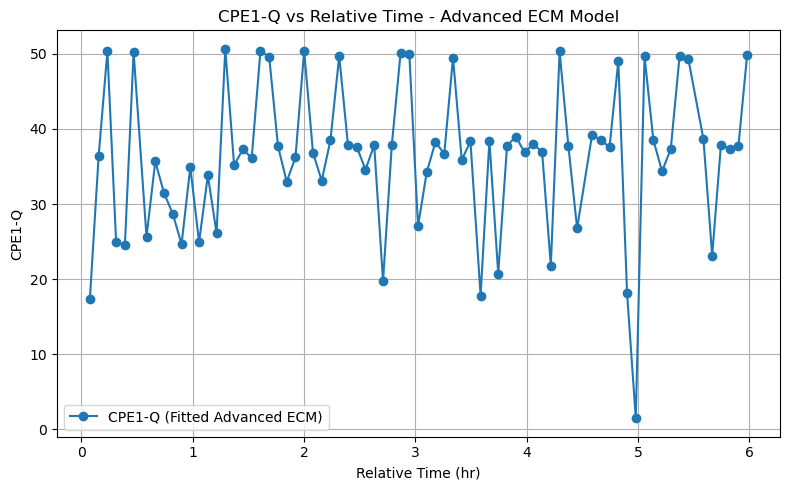

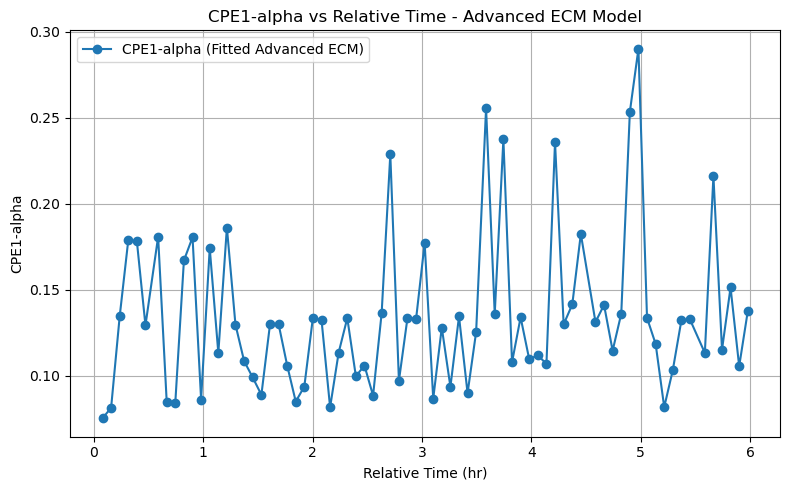

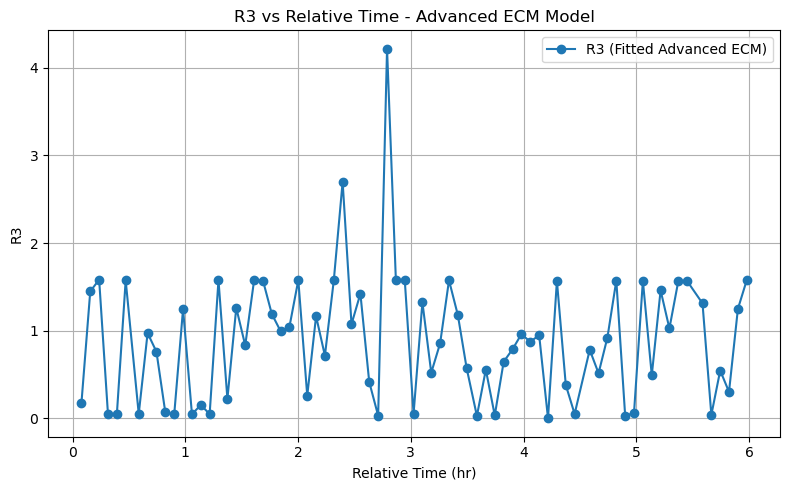

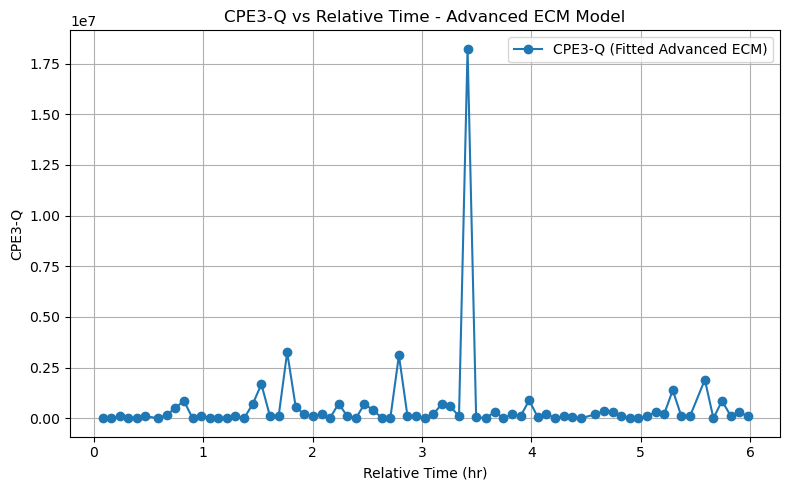

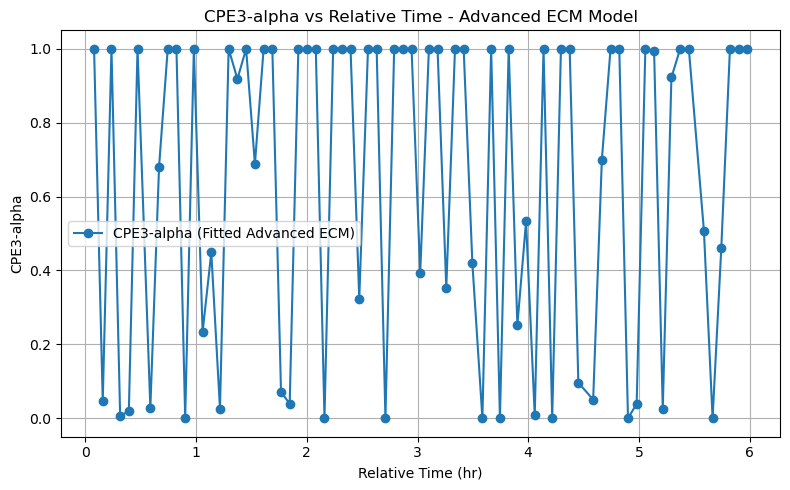

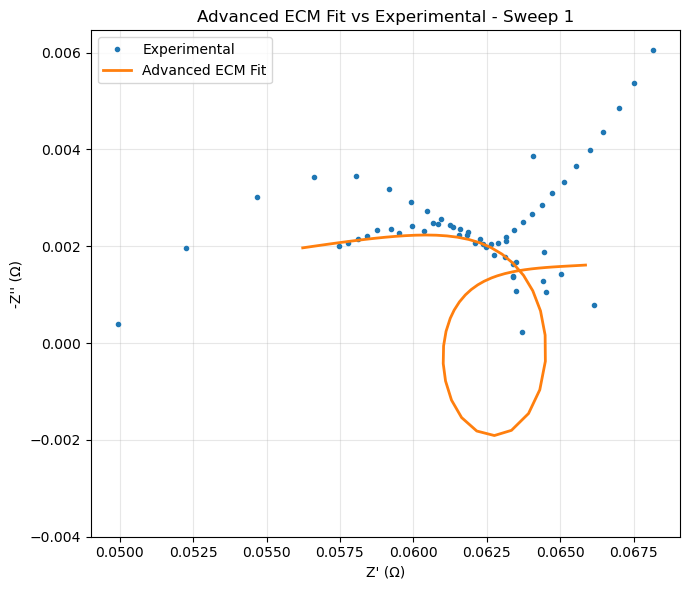

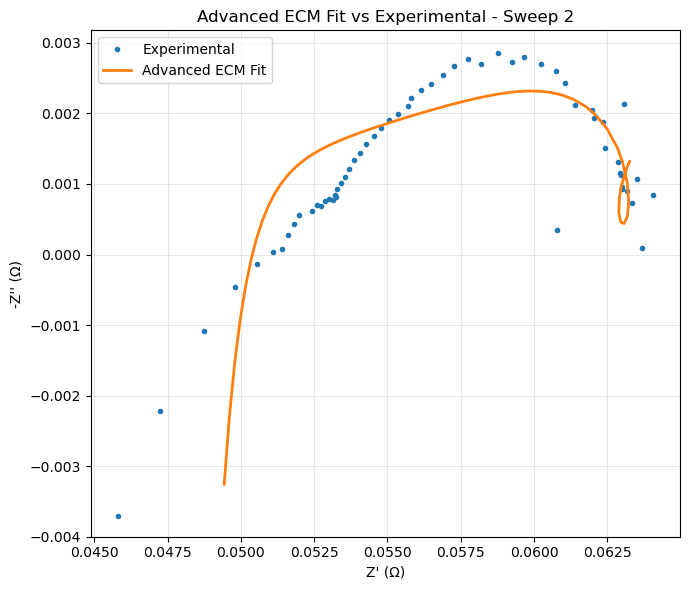

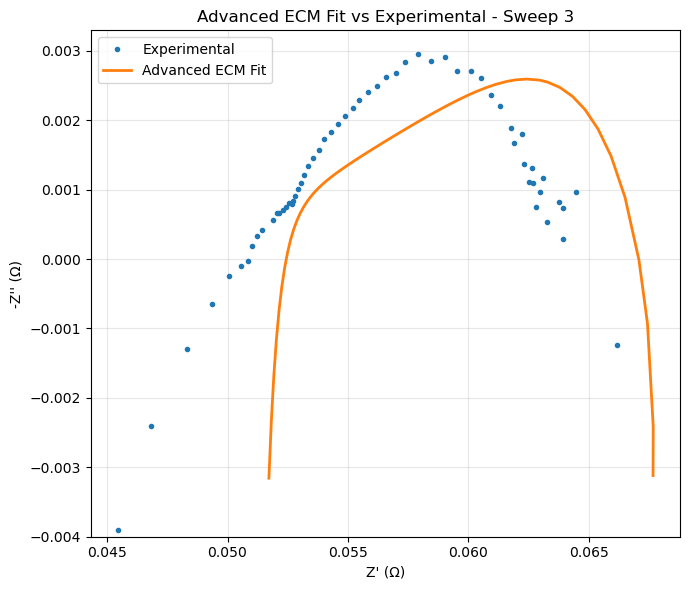

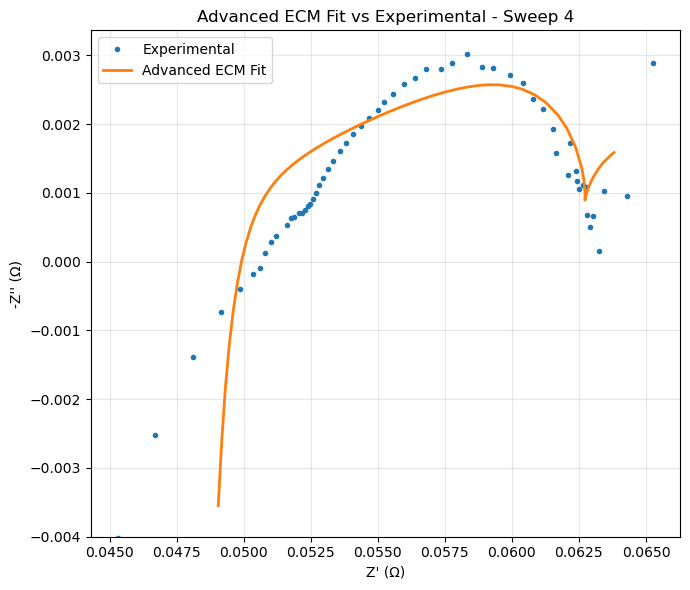

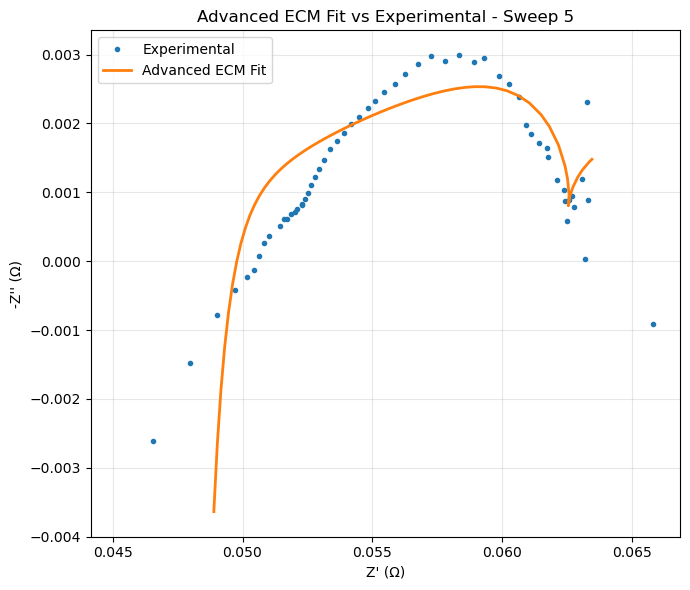

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from pathlib import Path

from impedance.models.circuits import CustomCircuit
from impedance import preprocessing

from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute

warnings.filterwarnings("ignore")

###############################################################################
# 1. DATA LOADING: MULTI-SHEET EXCEL (6300.xls)
###############################################################################
file_path = "6300.xls"  # Path to your Excel file
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Prefer the "Probe Frequency Domain" sheet if available
if "Probe Frequency Domain" in all_sheets and not all_sheets["Probe Frequency Domain"].empty:
    df_eis = all_sheets["Probe Frequency Domain"]
    print("Using sheet: 'Probe Frequency Domain'")
elif "EIS_Data" in all_sheets and not all_sheets["EIS_Data"].empty:
    df_eis = all_sheets["EIS_Data"]
    print("Using sheet: 'EIS_Data'")
else:
    for sheet_name, sheet_df in all_sheets.items():
        if not sheet_df.empty:
            df_eis = sheet_df
            print(f"Using sheet: '{sheet_name}' (fallback)")
            break
    else:
        raise ValueError("No nonempty sheet found in 6300.xls.")

###############################################################################
# 2. DATA CLEANUP & TIME DERIVATION
###############################################################################
print("Available columns before renaming:", df_eis.columns.tolist())
rename_map = {
    "Frequency (Hz)": "frequency",
    "Real Impedance Re{z}(Ω)": "Z_real",
    "Negative Imaginary Impedance -Im{z}(Ω)": "Z_imag_neg",
    "Time": "time"
}
df_eis.rename(columns=rename_map, inplace=True)
print("Available columns after renaming:", df_eis.columns.tolist())

required_cols = ["frequency", "Z_real", "Z_imag_neg"]
missing = [col for col in required_cols if col not in df_eis.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}.")
df_eis.dropna(subset=required_cols, inplace=True)

if "time" in df_eis.columns:
    df_eis["time"] = pd.to_datetime(df_eis["time"], errors="coerce")
    df_eis.dropna(subset=["time"], inplace=True)
    df_eis["RelTime_sec"] = (df_eis["time"] - df_eis["time"].min()).dt.total_seconds()
    df_eis["RelTime_hr"] = df_eis["RelTime_sec"] / 3600
else:
    df_eis["RelTime_hr"] = np.arange(len(df_eis)) * 0.1

df_eis["sweep_id"] = df_eis.groupby("time").ngroup() if "time" in df_eis.columns else 0

###############################################################################
# 3. AUTO-FEATURIZATION WITH TSFRESH (OPTIONAL)
###############################################################################
df_tsfresh = df_eis[["sweep_id", "frequency", "Z_real"]].rename(
    columns={"sweep_id": "id", "frequency": "time", "Z_real": "value"}
)
extracted_features = extract_features(df_tsfresh, column_id="id", column_sort="time", n_jobs=0)
extracted_features = impute(extracted_features)
extracted_features.reset_index(inplace=True)
extracted_features.rename(columns={"index": "sweep_id"}, inplace=True)
extracted_features.to_excel("ecm_features.xlsx", index=False)
print("TSFRESH features saved to 'ecm_features.xlsx'.")

###############################################################################
# 4. DEFINE ECM MODELS WITH INITIAL GUESSES
###############################################################################
# Advanced model candidate information
advanced_model_info = {
    "name": "Advanced_2RCPE",
    "circuit": "L0-R0-p(R1-L1, R2-CPE1, R3-CPE3)",
    "initial_guess": [
        0.0,       # L0
        0.04941,   # R0
        0.0083883, # R1
        2.0785,    # L1
        0.0083683, # R2
        0.46421,   # CPE1-Q
        1.0,       # CPE1-alpha
        2.2071,    # R3
        1.0,       # CPE3-Q
        1.0        # CPE3-alpha
    ],
    "param_names": ["L0", "R0", "R1", "L1", "R2", "CPE1-Q", "CPE1-alpha", "R3", "CPE3-Q", "CPE3-alpha"]
}

# (You can define other candidate models if needed; here we focus on advanced_model_info)
model_candidates = [advanced_model_info]

###############################################################################
# 5. ECM FITTING FUNCTION FOR ADVANCED MODEL
###############################################################################
def fit_and_evaluate_model(model_dict, freq, Z_exp):
    circuit_str = model_dict["circuit"]
    init_guess = model_dict["initial_guess"]
    circuit_model = CustomCircuit(circuit=circuit_str, initial_guess=init_guess)
    circuit_model.fit(freq, Z_exp)
    Z_fit = circuit_model.predict(freq)
    residuals = Z_exp - Z_fit
    rmse = np.sqrt(np.mean(np.abs(residuals)**2))
    n = len(freq)
    k = len(circuit_model.parameters_)
    rss = np.sum(np.abs(residuals)**2)
    N_eff = 2 * n
    aic = 2 * k + N_eff * np.log(rss / N_eff + 1e-15)
    bic = np.log(N_eff) * k + N_eff * np.log(rss / N_eff + 1e-15)
    param_names = model_dict["param_names"]
    fitted_params = circuit_model.parameters_
    for name, value in zip(param_names, fitted_params):
        if (name.startswith('R') or name.startswith('L')) and value < 0:
            return None
    return {
        "model_name": model_dict["name"],
        "params": fitted_params,
        "param_names": param_names,
        "rmse": rmse,
        "aic": aic,
        "bic": bic
    }

# For simplicity, fit the advanced model for each sweep
fit_results = []
for sweep_id, group in df_eis.groupby("sweep_id"):
    group = group.sort_values("frequency")
    if len(group) < 3:
        continue
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    if not np.all(np.isfinite(Z_exp)) or np.any(freq <= 0):
        continue
    result = fit_and_evaluate_model(advanced_model_info, freq, Z_exp)
    if result is not None and (result["rmse"]/np.mean(np.abs(Z_exp))*100) <= 10.0:
        time_val = group["time"].iloc[0] if "time" in group.columns else None
        rel_time_hr = group["RelTime_hr"].iloc[0] if "RelTime_hr" in group.columns else None
        result.update({"sweep_id": sweep_id, "time": time_val, "RelTime_hr": rel_time_hr})
        fit_results.append(result)

fit_df = pd.DataFrame(fit_results)
if fit_df.empty:
    raise RuntimeError("No valid advanced model ECM fits found.")
fit_df.to_excel("ECM_fitting_results_advanced.xlsx", index=False)
print("Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'")
print(fit_df.head())

###############################################################################
# 6. PLOT ADVANCED MODEL PARAMETERS VS. EXPERIMENTAL VALUES 
###############################################################################
# Expand advanced model parameters into separate columns
param_names = advanced_model_info["param_names"]
for i, pname in enumerate(param_names):
    fit_df[pname] = fit_df["params"].apply(lambda x: x[i] if len(x) > i else np.nan)

# Merge relative time from df_eis if not already present
if "RelTime_hr" not in fit_df.columns:
    rel_time = df_eis.groupby("sweep_id")["RelTime_hr"].mean().reset_index()
    fit_df = pd.merge(fit_df, rel_time, on="sweep_id", how="left")

# Plot each parameter vs relative time in separate plots
for pname in param_names:
    plt.figure(figsize=(8, 5))
    plt.plot(fit_df["RelTime_hr"], fit_df[pname], 'o-', label=f'{pname} (Fitted Advanced ECM)') 
    plt.xlabel("Relative Time (hr)")
    plt.ylabel(pname)
    plt.title(f"{pname} vs Relative Time - Advanced ECM Model")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

###############################################################################
# 7. COMPARE ADVANCED MODEL FIT (ECM) VS EXPERIMENTAL (NYQUIST PLOT)
###############################################################################
# Select a specific sweep to compare advanced model fit vs experimental
sweep_to_plot_ids = fit_df["sweep_id"].iloc[0:5]

# Iterate through each sweep ID to plot
for sweep_id in sweep_to_plot_ids:
    # Filter data for the current sweep
    group = df_eis[df_eis["sweep_id"] == sweep_id].sort_values("frequency")
    freq_plot = group["frequency"].values
    Z_exp_plot = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)

    # Use the advanced model fit for the current sweep
    advanced_row = fit_df[fit_df["sweep_id"] == sweep_id].iloc[0]
    circuit_adv = CustomCircuit(circuit=advanced_model_info["circuit"], initial_guess=advanced_model_info["initial_guess"])
    circuit_adv.parameters_ = advanced_row["params"]
    Z_fit_adv = circuit_adv.predict(freq_plot)

    # Plot Nyquist comparison
    plt.figure(figsize=(7, 6))
    plt.plot(Z_exp_plot.real, -Z_exp_plot.imag, 'o', label='Experimental', markersize=3)
    plt.plot(Z_fit_adv.real, -Z_fit_adv.imag, '-', label='Advanced ECM Fit', linewidth=2)
    plt.xlabel("Z' (Ω)")
    plt.ylabel("-Z'' (Ω)")
    plt.title(f'Advanced ECM Fit vs Experimental - Sweep {sweep_id}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.ylim(-0.004, None)
    plt.tight_layout()
    plt.show()

Using sheet: 'Probe Frequency Domain'
Available columns before renaming: ['Probe', 'Time', 'Frequency (Hz)', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Real Impedance Re{z}(Ω)', 'Negative Imaginary Impedance -Im{z}(Ω)']
Available columns after renaming: ['Probe', 'time', 'frequency', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Z_real', 'Z_imag_neg']


Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 75/75 [00:07<00:00, 10.13it/s]


TSFRESH features saved to 'ecm_features.xlsx'.
Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'
       model_name                                             params  \
0  Advanced_2RCPE  [5e-324, 0.03761107914520926, 0.07902309698904...   
1  Advanced_2RCPE  [7.045384613262934e-09, 0.04027785016605508, 0...   
2  Advanced_2RCPE  [6.0967988626392084e-09, 0.032068462567683656,...   
3  Advanced_2RCPE  [7.057724824939383e-09, 0.04573823685960637, 0...   
4  Advanced_2RCPE  [7.210451107219214e-09, 0.04551139213412436, 0...   

                                         param_names      rmse          aic  \
0  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.003102 -1449.332705   
1  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000943 -1735.138415   
2  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.002043 -1549.565608   
3  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000925 -1739.762860   
4  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.0009

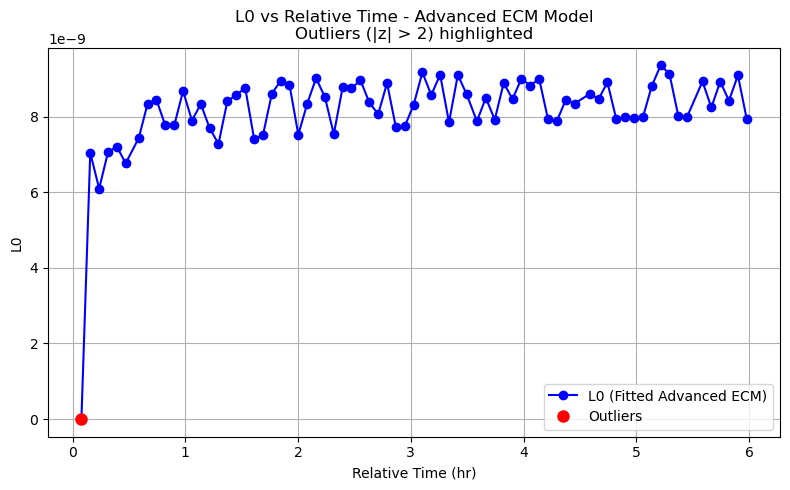

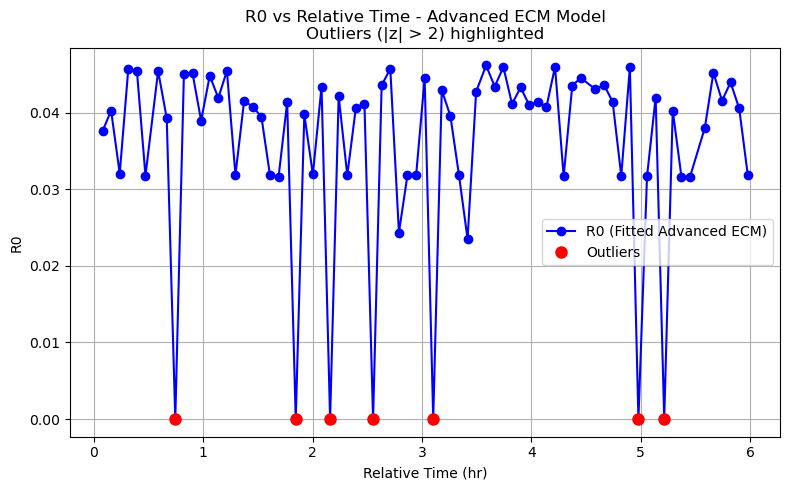

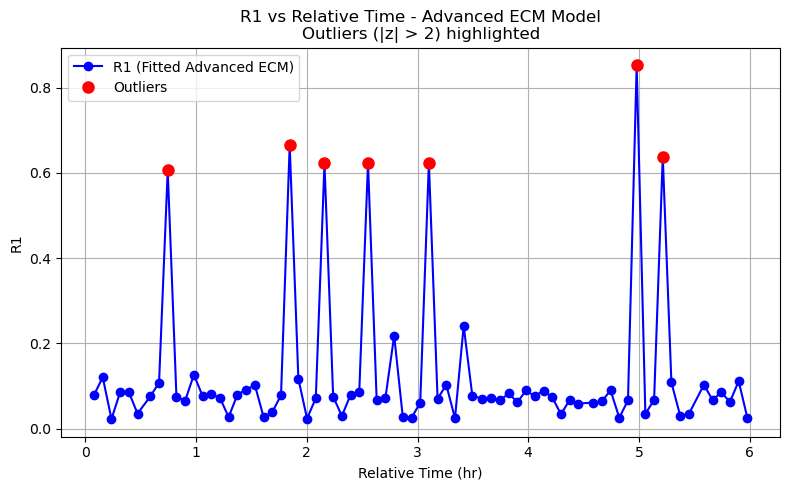

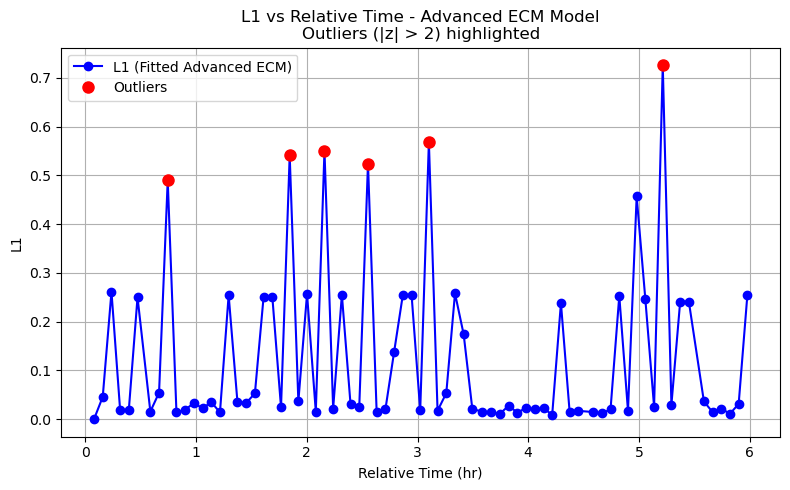

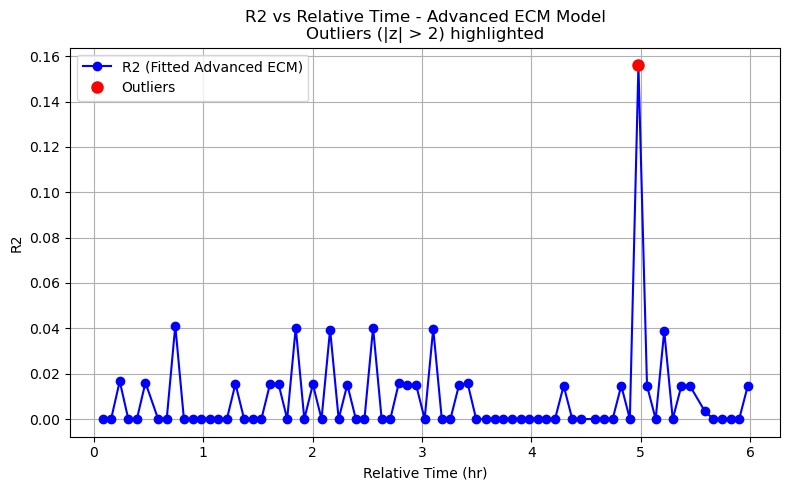

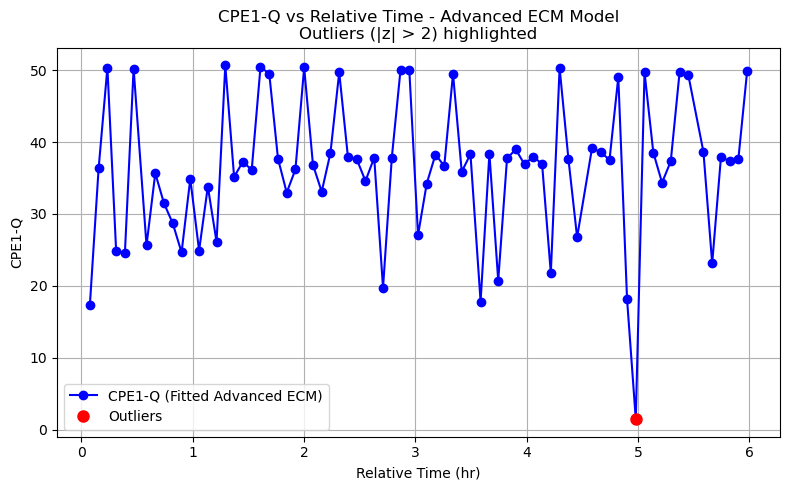

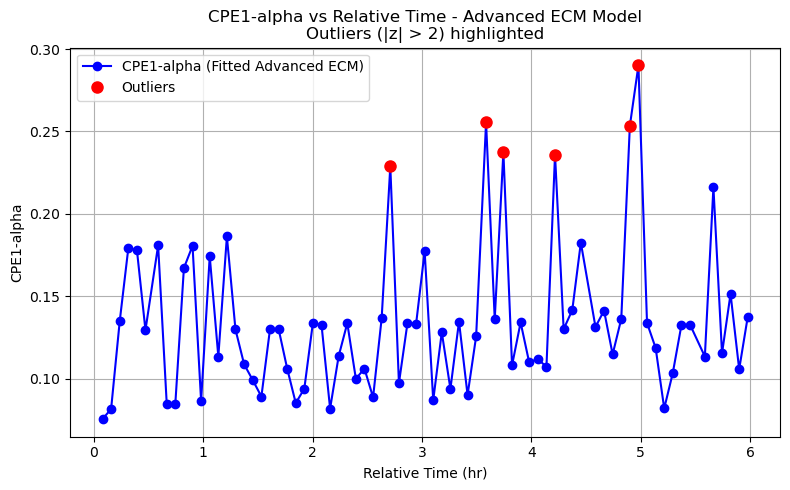

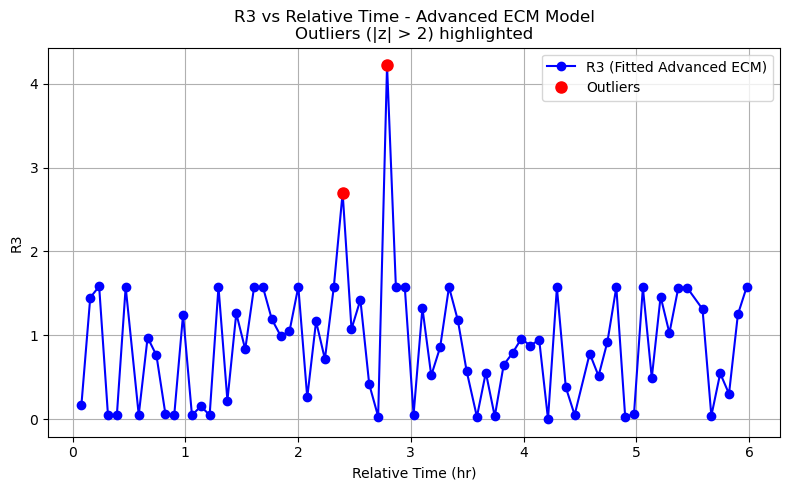

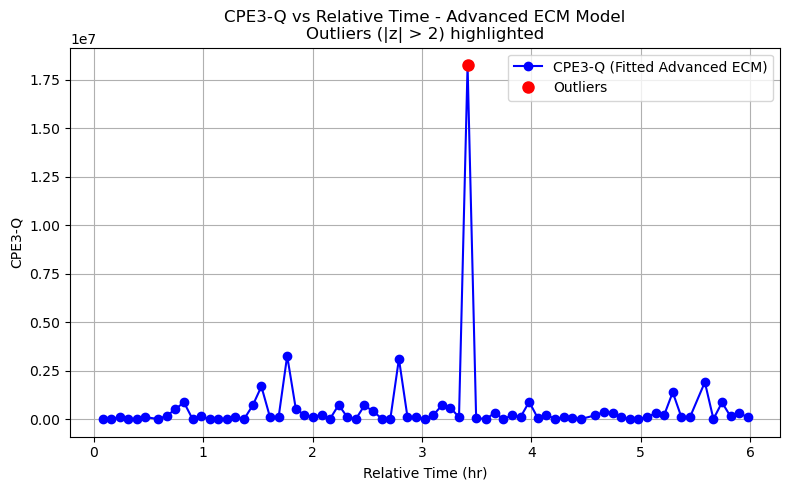

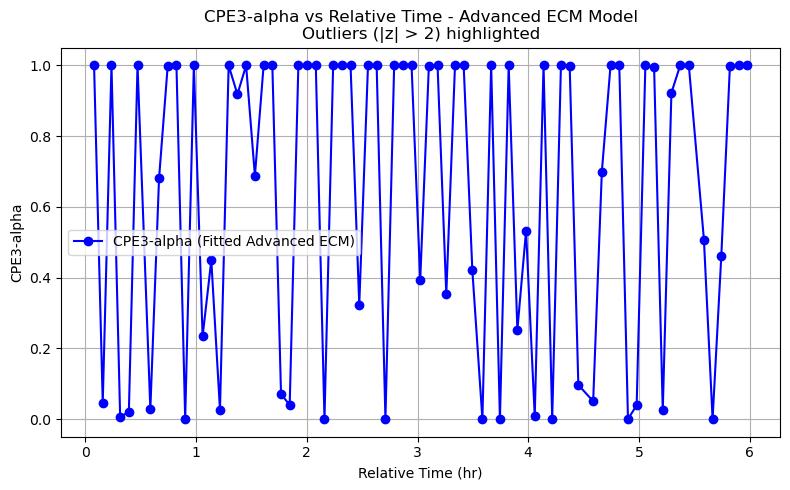

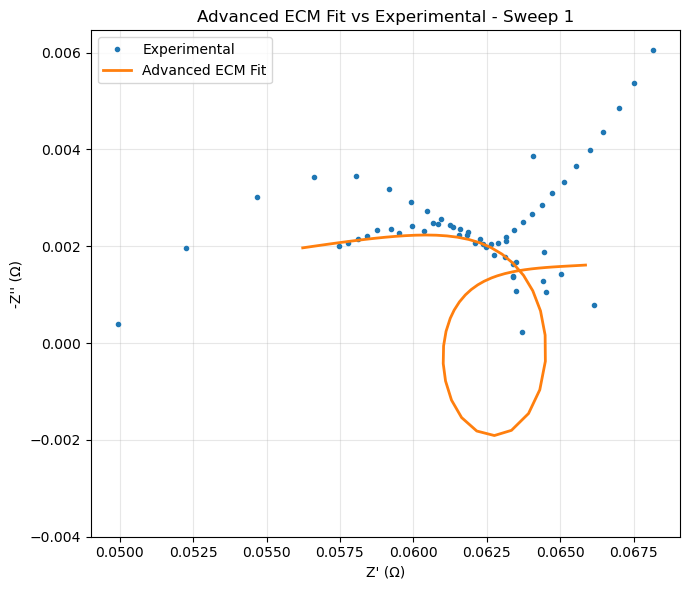

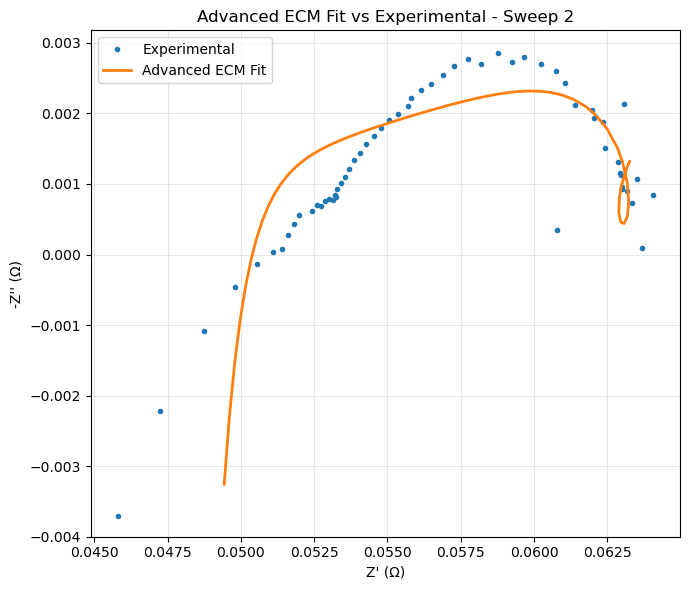

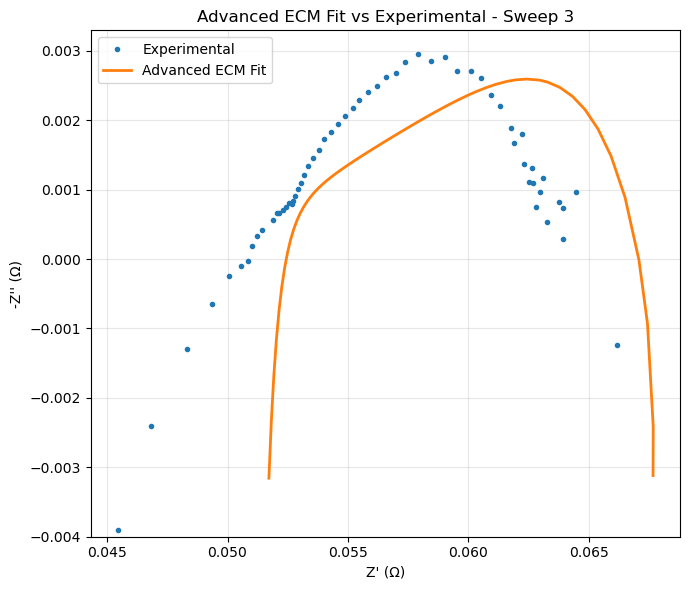

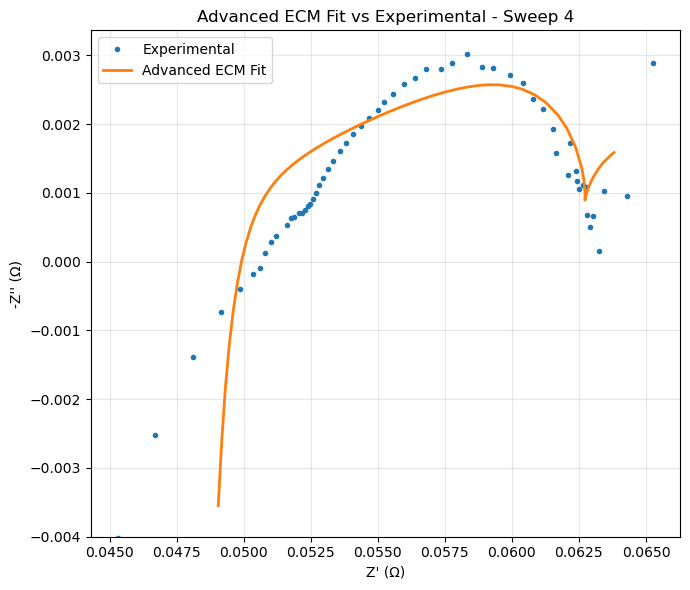

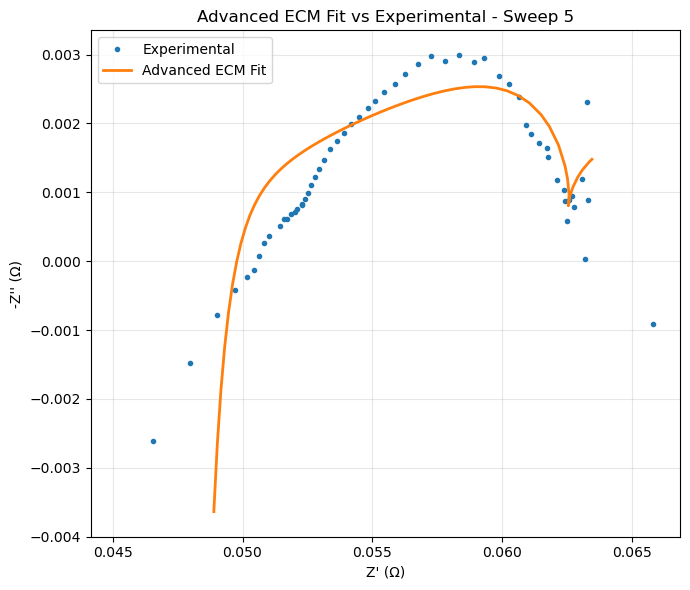

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from pathlib import Path

from impedance.models.circuits import CustomCircuit
from impedance import preprocessing

from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute

warnings.filterwarnings("ignore")

###############################################################################
# 1. DATA LOADING: MULTI-SHEET EXCEL (6300.xls)
###############################################################################
file_path = "6300.xls"  # Path to your Excel file
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Prefer the "Probe Frequency Domain" sheet if available
if "Probe Frequency Domain" in all_sheets and not all_sheets["Probe Frequency Domain"].empty:
    df_eis = all_sheets["Probe Frequency Domain"]
    print("Using sheet: 'Probe Frequency Domain'")
elif "EIS_Data" in all_sheets and not all_sheets["EIS_Data"].empty:
    df_eis = all_sheets["EIS_Data"]
    print("Using sheet: 'EIS_Data'")
else:
    for sheet_name, sheet_df in all_sheets.items():
        if not sheet_df.empty:
            df_eis = sheet_df
            print(f"Using sheet: '{sheet_name}' (fallback)")
            break
    else:
        raise ValueError("No nonempty sheet found in 6300.xls.")

###############################################################################
# 2. DATA CLEANUP & TIME DERIVATION
###############################################################################
print("Available columns before renaming:", df_eis.columns.tolist())
rename_map = {
    "Frequency (Hz)": "frequency",
    "Real Impedance Re{z}(Ω)": "Z_real",
    "Negative Imaginary Impedance -Im{z}(Ω)": "Z_imag_neg",
    "Time": "time"
}
df_eis.rename(columns=rename_map, inplace=True)
print("Available columns after renaming:", df_eis.columns.tolist())

required_cols = ["frequency", "Z_real", "Z_imag_neg"]
missing = [col for col in required_cols if col not in df_eis.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}.")
df_eis.dropna(subset=required_cols, inplace=True)

if "time" in df_eis.columns:
    df_eis["time"] = pd.to_datetime(df_eis["time"], errors="coerce")
    df_eis.dropna(subset=["time"], inplace=True)
    df_eis["RelTime_sec"] = (df_eis["time"] - df_eis["time"].min()).dt.total_seconds()
    df_eis["RelTime_hr"] = df_eis["RelTime_sec"] / 3600
else:
    df_eis["RelTime_hr"] = np.arange(len(df_eis)) * 0.1

df_eis["sweep_id"] = df_eis.groupby("time").ngroup() if "time" in df_eis.columns else 0

###############################################################################
# 3. AUTO-FEATURIZATION WITH TSFRESH (OPTIONAL)
###############################################################################
df_tsfresh = df_eis[["sweep_id", "frequency", "Z_real"]].rename(
    columns={"sweep_id": "id", "frequency": "time", "Z_real": "value"}
)
extracted_features = extract_features(df_tsfresh, column_id="id", column_sort="time", n_jobs=0)
extracted_features = impute(extracted_features)
extracted_features.reset_index(inplace=True)
extracted_features.rename(columns={"index": "sweep_id"}, inplace=True)
extracted_features.to_excel("ecm_features.xlsx", index=False)
print("TSFRESH features saved to 'ecm_features.xlsx'.")

###############################################################################
# 4. DEFINE ECM MODELS WITH INITIAL GUESSES
###############################################################################
# Advanced model candidate information
advanced_model_info = {
    "name": "Advanced_2RCPE",
    "circuit": "L0-R0-p(R1-L1, R2-CPE1, R3-CPE3)",
    "initial_guess": [
        0.0,       # L0
        0.04941,   # R0
        0.0083883, # R1
        2.0785,    # L1
        0.0083683, # R2
        0.46421,   # CPE1-Q
        1.0,       # CPE1-alpha
        2.2071,    # R3
        1.0,       # CPE3-Q
        1.0        # CPE3-alpha
    ],
    "param_names": ["L0", "R0", "R1", "L1", "R2", "CPE1-Q", "CPE1-alpha", "R3", "CPE3-Q", "CPE3-alpha"]
}

# (You can define other candidate models if needed; here we focus on advanced_model_info)
model_candidates = [advanced_model_info]

###############################################################################
# 5. ECM FITTING FUNCTION FOR ADVANCED MODEL
###############################################################################
def fit_and_evaluate_model(model_dict, freq, Z_exp):
    circuit_str = model_dict["circuit"]
    init_guess = model_dict["initial_guess"]
    circuit_model = CustomCircuit(circuit=circuit_str, initial_guess=init_guess)
    circuit_model.fit(freq, Z_exp)
    Z_fit = circuit_model.predict(freq)
    residuals = Z_exp - Z_fit
    rmse = np.sqrt(np.mean(np.abs(residuals)**2))
    n = len(freq)
    k = len(circuit_model.parameters_)
    rss = np.sum(np.abs(residuals)**2)
    N_eff = 2 * n
    aic = 2 * k + N_eff * np.log(rss / N_eff + 1e-15)
    bic = np.log(N_eff) * k + N_eff * np.log(rss / N_eff + 1e-15)
    param_names = model_dict["param_names"]
    fitted_params = circuit_model.parameters_
    for name, value in zip(param_names, fitted_params):
        if (name.startswith('R') or name.startswith('L')) and value < 0:
            return None
    return {
        "model_name": model_dict["name"],
        "params": fitted_params,
        "param_names": param_names,
        "rmse": rmse,
        "aic": aic,
        "bic": bic
    }

# For simplicity, fit the advanced model for each sweep
fit_results = []
for sweep_id, group in df_eis.groupby("sweep_id"):
    group = group.sort_values("frequency")
    if len(group) < 3:
        continue
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    if not np.all(np.isfinite(Z_exp)) or np.any(freq <= 0):
        continue
    result = fit_and_evaluate_model(advanced_model_info, freq, Z_exp)
    if result is not None and (result["rmse"]/np.mean(np.abs(Z_exp))*100) <= 10.0:
        time_val = group["time"].iloc[0] if "time" in group.columns else None
        rel_time_hr = group["RelTime_hr"].iloc[0] if "RelTime_hr" in group.columns else None
        result.update({"sweep_id": sweep_id, "time": time_val, "RelTime_hr": rel_time_hr})
        fit_results.append(result)

fit_df = pd.DataFrame(fit_results)
if fit_df.empty:
    raise RuntimeError("No valid advanced model ECM fits found.")
fit_df.to_excel("ECM_fitting_results_advanced.xlsx", index=False)
print("Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'")
print(fit_df.head())

###############################################################################
# 6. PLOT ADVANCED MODEL PARAMETERS VS. EXPERIMENTAL VALUES WITH OUTLIER DETECTION
###############################################################################
# Expand advanced model parameters into separate columns
param_names = advanced_model_info["param_names"]
for i, pname in enumerate(param_names):
    fit_df[pname] = fit_df["params"].apply(lambda x: x[i] if len(x) > i else np.nan)

# Merge relative time from df_eis if not already present
if "RelTime_hr" not in fit_df.columns:
    rel_time = df_eis.groupby("sweep_id")["RelTime_hr"].mean().reset_index()
    fit_df = pd.merge(fit_df, rel_time, on="sweep_id", how="left")

# Plot each parameter vs. relative time and highlight outliers
for pname in param_names:
    plt.figure(figsize=(8, 5))
    plt.plot(fit_df["RelTime_hr"], fit_df[pname], 'bo-', label=f'{pname} (Fitted Advanced ECM)')
    
    # Compute z-scores and flag outliers (|z| > 2)
    z_scores = (fit_df[pname] - fit_df[pname].mean()) / fit_df[pname].std()
    outliers = fit_df[abs(z_scores) > 2]
    if not outliers.empty:
        plt.plot(outliers["RelTime_hr"], outliers[pname], 'ro', markersize=8, label='Outliers')
    
    plt.xlabel("Relative Time (hr)")
    plt.ylabel(pname)
    plt.title(f"{pname} vs Relative Time - Advanced ECM Model\nOutliers (|z| > 2) highlighted")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

###############################################################################
# 7. COMPARE ADVANCED MODEL FIT (ECM) VS EXPERIMENTAL (NYQUIST PLOT)
###############################################################################
# Select a specific sweep to compare advanced model fit vs experimental
sweep_to_plot_ids = fit_df["sweep_id"].iloc[0:5]

# Iterate through each sweep ID to plot
for sweep_id in sweep_to_plot_ids:
    # Filter data for the current sweep
    group = df_eis[df_eis["sweep_id"] == sweep_id].sort_values("frequency")
    freq_plot = group["frequency"].values
    Z_exp_plot = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)

    # Use the advanced model fit for the current sweep
    advanced_row = fit_df[fit_df["sweep_id"] == sweep_id].iloc[0]
    circuit_adv = CustomCircuit(circuit=advanced_model_info["circuit"], initial_guess=advanced_model_info["initial_guess"])
    circuit_adv.parameters_ = advanced_row["params"]
    Z_fit_adv = circuit_adv.predict(freq_plot)

    # Plot Nyquist comparison
    plt.figure(figsize=(7, 6))
    plt.plot(Z_exp_plot.real, -Z_exp_plot.imag, 'o', label='Experimental', markersize=3)
    plt.plot(Z_fit_adv.real, -Z_fit_adv.imag, '-', label='Advanced ECM Fit', linewidth=2)
    plt.xlabel("Z' (Ω)")
    plt.ylabel("-Z'' (Ω)")
    plt.title(f'Advanced ECM Fit vs Experimental - Sweep {sweep_id}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.ylim(-0.004, None)
    plt.tight_layout()
    plt.show()

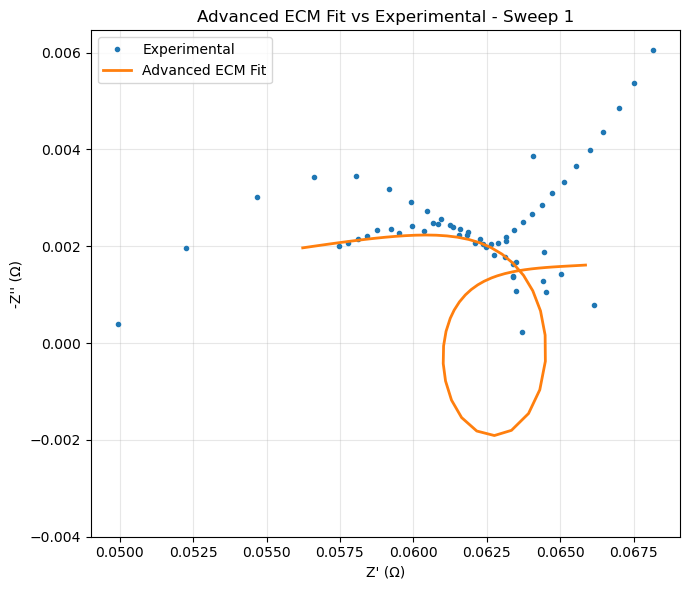

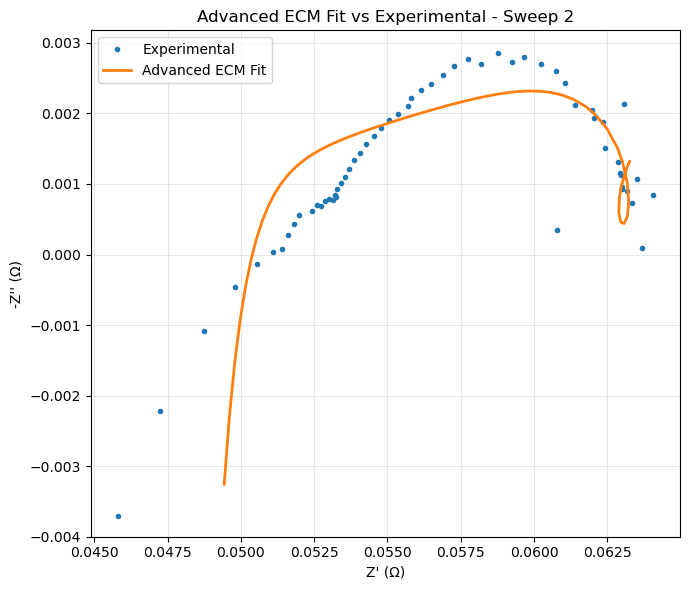

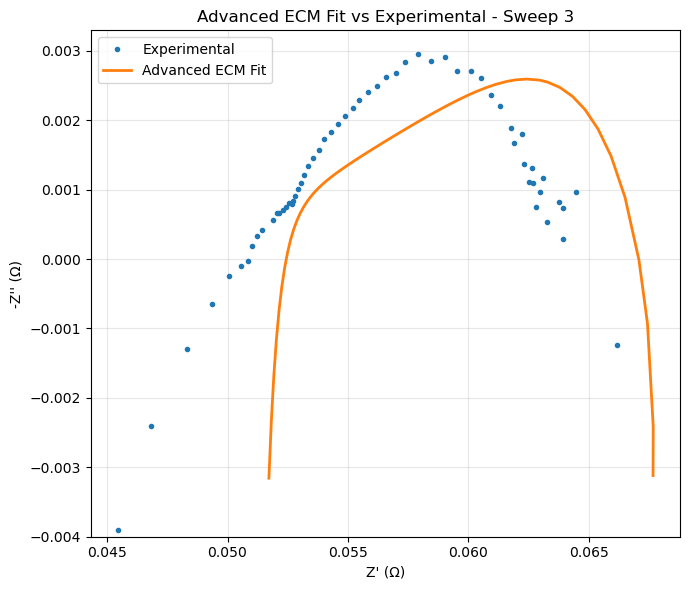

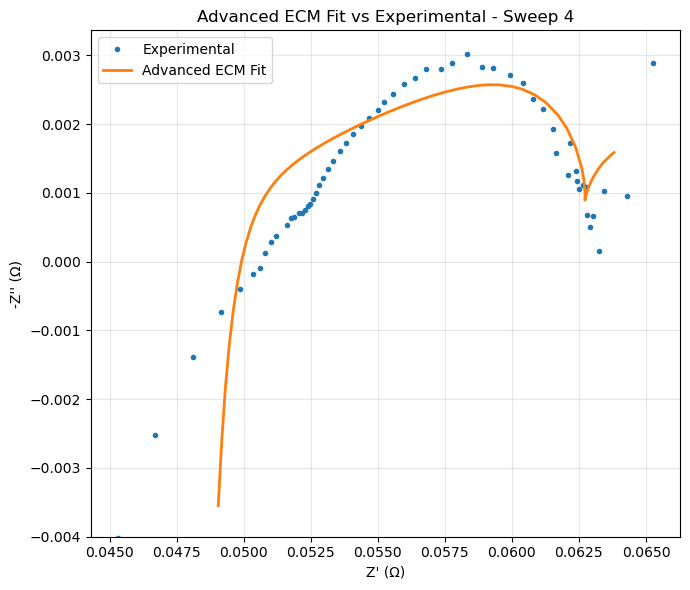

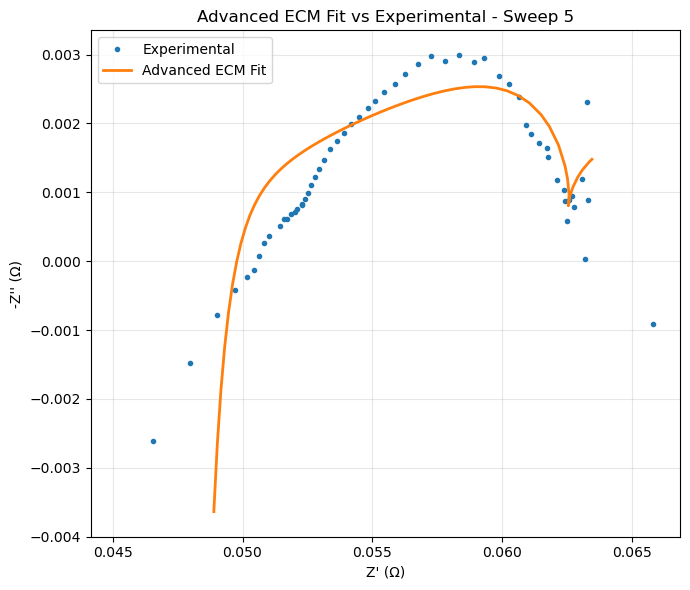

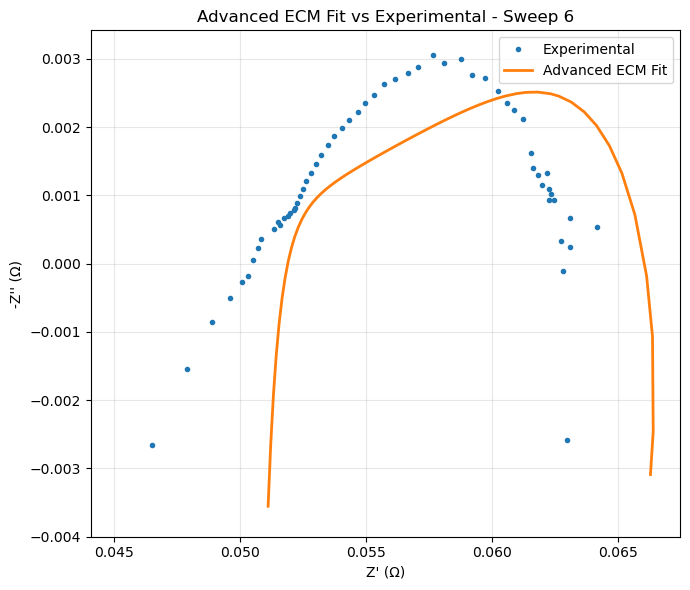

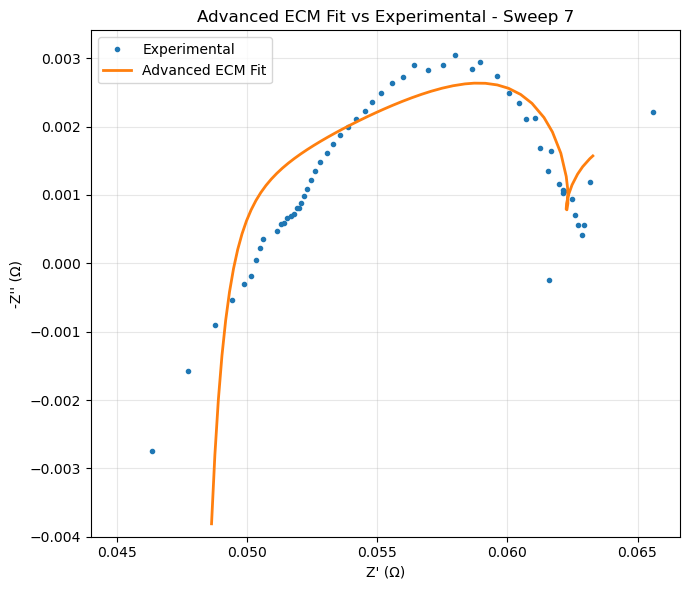

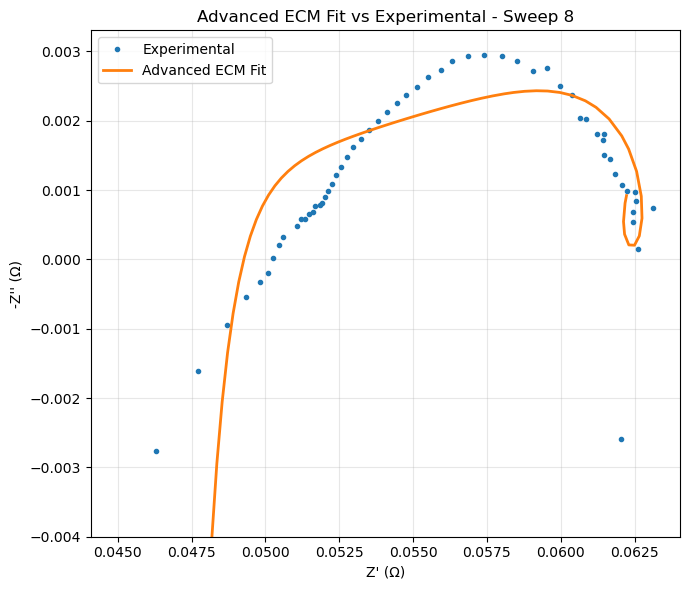

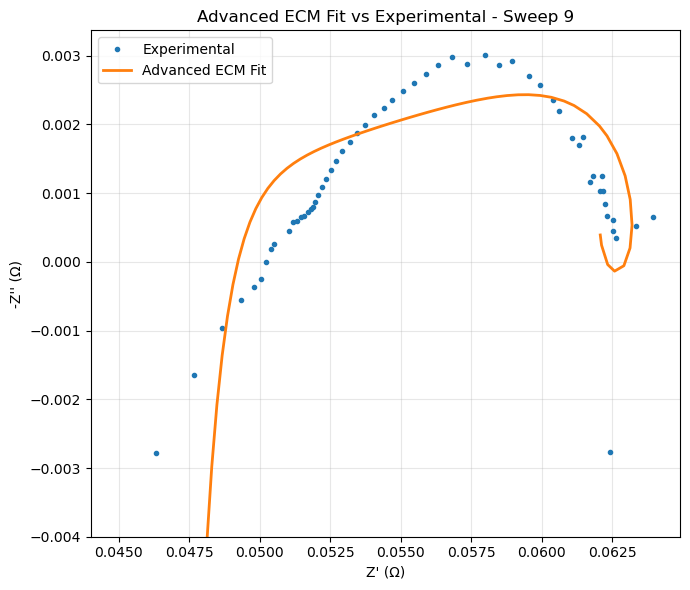

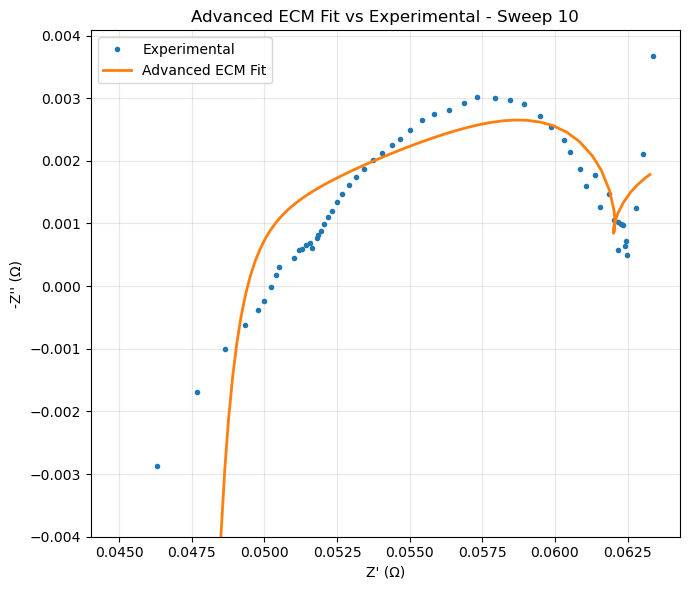

In [6]:
sweep_to_plot_ids = fit_df["sweep_id"].iloc[0:10]

# Iterate through each sweep ID to plot
for sweep_id in sweep_to_plot_ids:
    # Filter data for the current sweep
    group = df_eis[df_eis["sweep_id"] == sweep_id].sort_values("frequency")
    freq_plot = group["frequency"].values
    Z_exp_plot = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)

    # Use the advanced model fit for the current sweep
    advanced_row = fit_df[fit_df["sweep_id"] == sweep_id].iloc[0]
    circuit_adv = CustomCircuit(circuit=advanced_model_info["circuit"], initial_guess=advanced_model_info["initial_guess"])
    circuit_adv.parameters_ = advanced_row["params"]
    Z_fit_adv = circuit_adv.predict(freq_plot)

    # Plot Nyquist comparison
    plt.figure(figsize=(7, 6))
    plt.plot(Z_exp_plot.real, -Z_exp_plot.imag, 'o', label='Experimental', markersize=3)
    plt.plot(Z_fit_adv.real, -Z_fit_adv.imag, '-', label='Advanced ECM Fit', linewidth=2)
    plt.xlabel("Z' (Ω)")
    plt.ylabel("-Z'' (Ω)")
    plt.title(f'Advanced ECM Fit vs Experimental - Sweep {sweep_id}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.ylim(-0.004, None)
    plt.tight_layout()
    plt.show()

Using sheet: 'Probe Frequency Domain'
Available columns before renaming: ['Probe', 'Time', 'Frequency (Hz)', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Real Impedance Re{z}(Ω)', 'Negative Imaginary Impedance -Im{z}(Ω)']
Available columns after renaming: ['Probe', 'time', 'frequency', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Z_real', 'Z_imag_neg']


Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 75/75 [00:06<00:00, 10.95it/s]


TSFRESH features saved to 'ecm_features.xlsx'.
Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'
       model_name                                             params  \
0  Advanced_2RCPE  [5e-324, 0.03761107914520926, 0.07902309698904...   
1  Advanced_2RCPE  [7.045384613262934e-09, 0.04027785016605508, 0...   
2  Advanced_2RCPE  [6.0967988626392084e-09, 0.032068462567683656,...   
3  Advanced_2RCPE  [7.057724824939383e-09, 0.04573823685960637, 0...   
4  Advanced_2RCPE  [7.210451107219214e-09, 0.04551139213412436, 0...   

                                         param_names      RMSE          AIC  \
0  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.003102 -1449.332705   
1  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000943 -1735.138415   
2  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.002043 -1549.565608   
3  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000925 -1739.762860   
4  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.0009

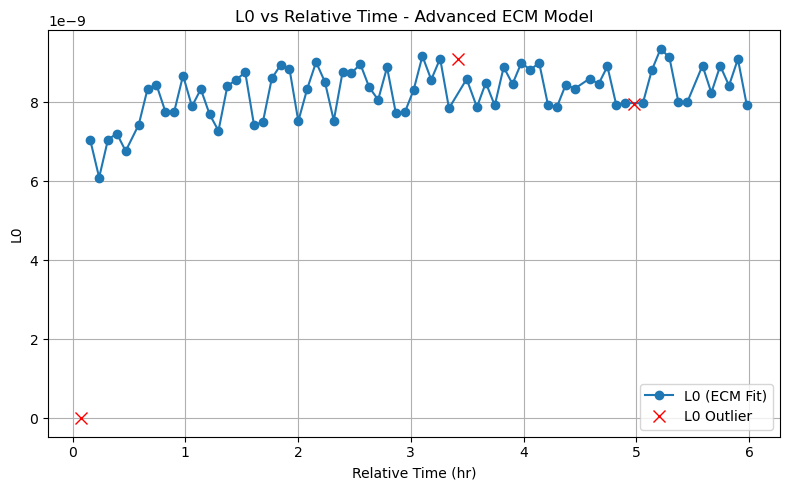

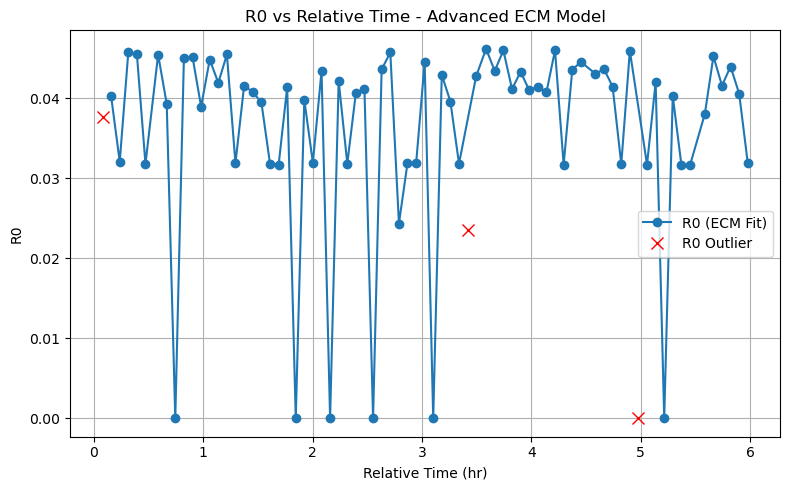

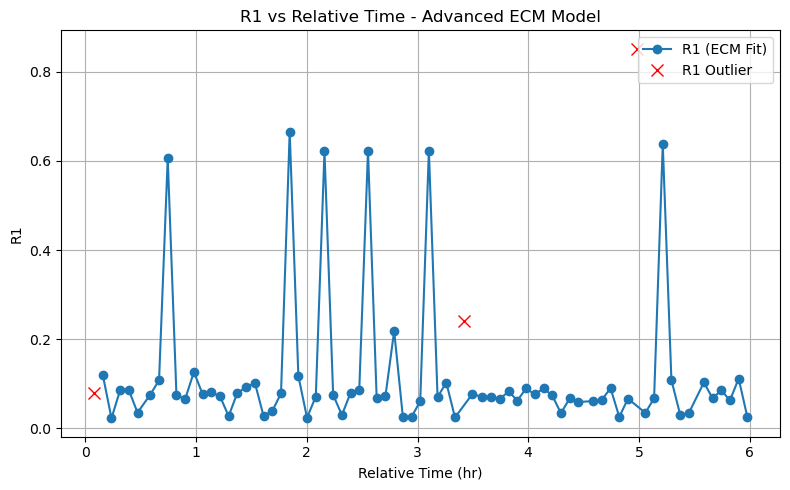

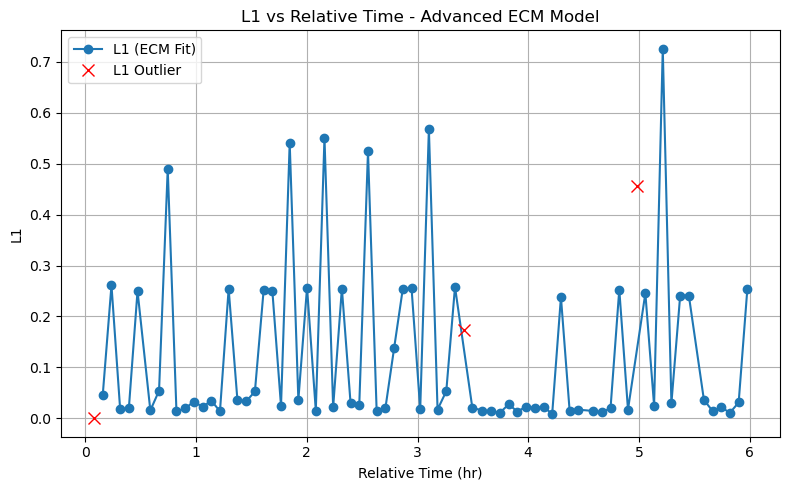

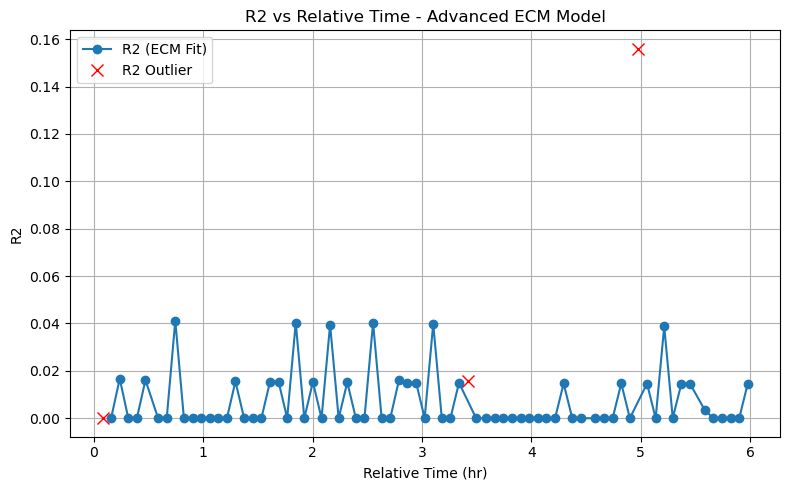

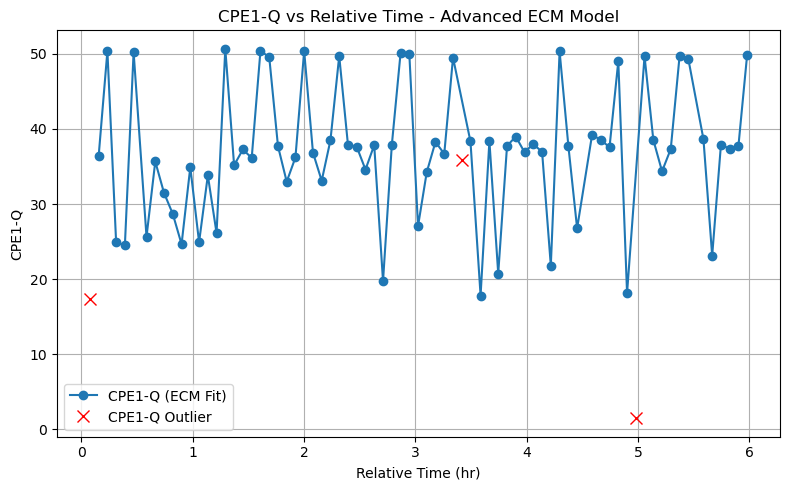

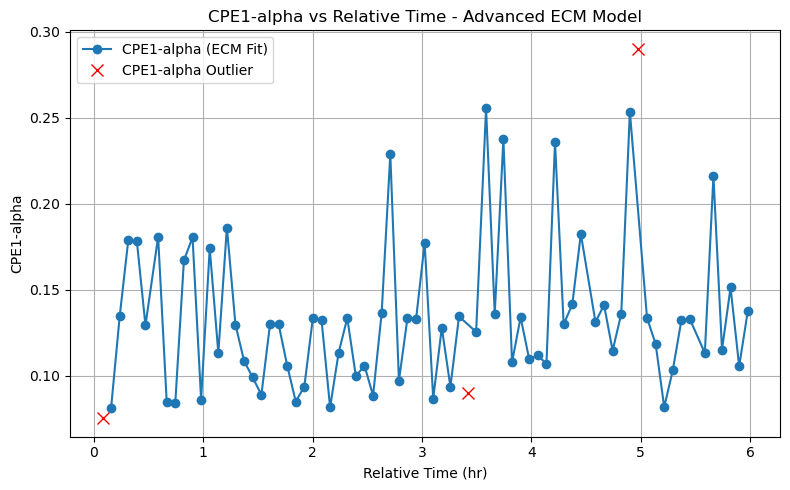

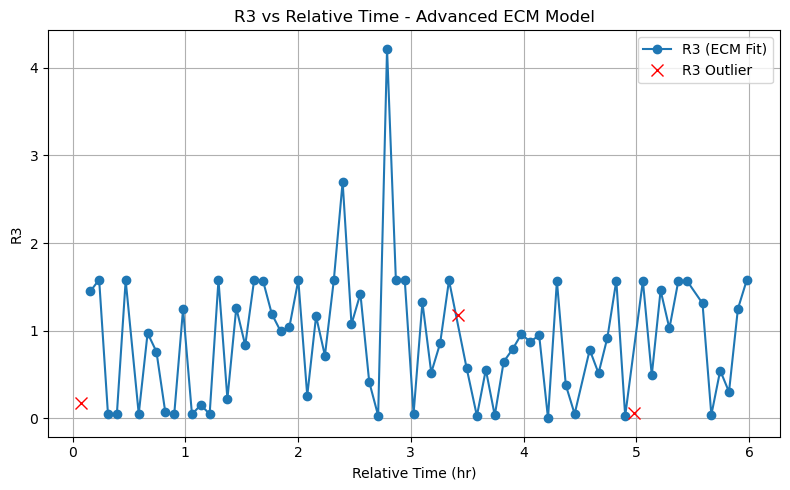

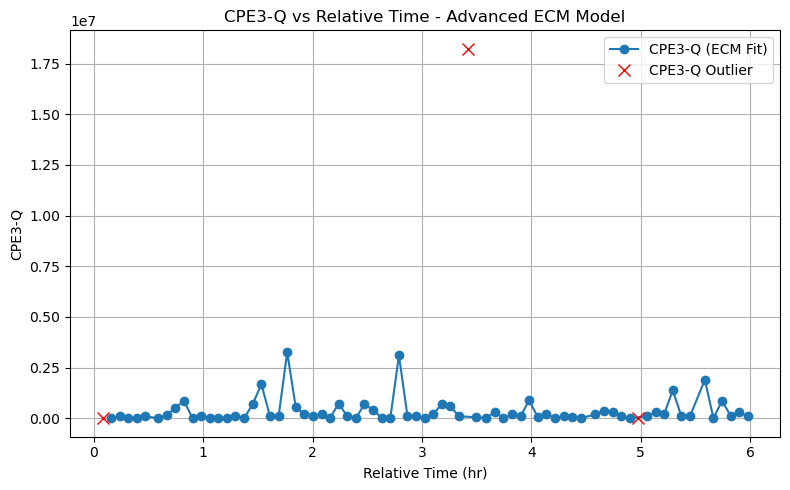

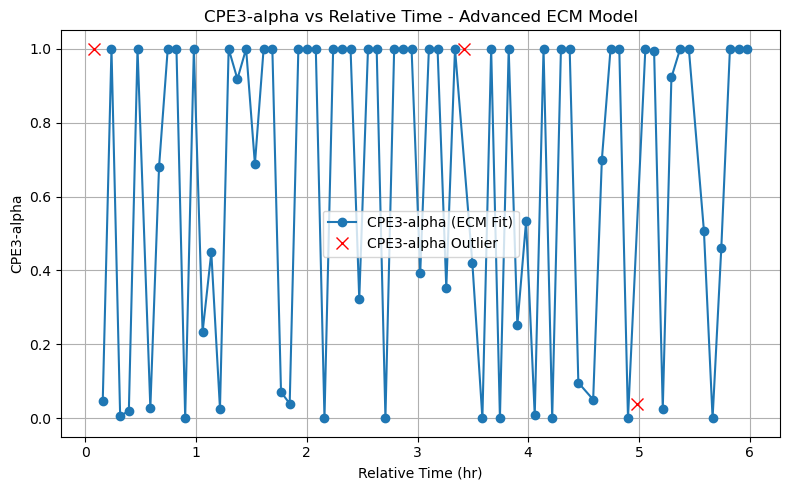

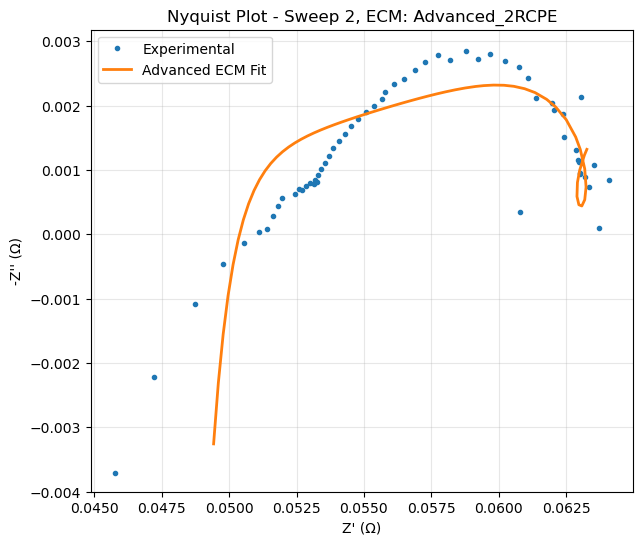

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from pathlib import Path

from impedance.models.circuits import CustomCircuit
from impedance import preprocessing

from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb

warnings.filterwarnings("ignore")

###############################################################################
# 1. DATA LOADING: MULTI-SHEET EXCEL (6300.xls)
###############################################################################
file_path = "6300.xls"  # Adjust file path as needed
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Prefer the "Probe Frequency Domain" sheet if available
if "Probe Frequency Domain" in all_sheets and not all_sheets["Probe Frequency Domain"].empty:
    df_eis = all_sheets["Probe Frequency Domain"]
    print("Using sheet: 'Probe Frequency Domain'")
elif "EIS_Data" in all_sheets and not all_sheets["EIS_Data"].empty:
    df_eis = all_sheets["EIS_Data"]
    print("Using sheet: 'EIS_Data'")
else:
    for sheet_name, sheet_df in all_sheets.items():
        if not sheet_df.empty:
            df_eis = sheet_df
            print(f"Using sheet: '{sheet_name}' (fallback)")
            break
    else:
        raise ValueError("No nonempty sheet found in 6300.xls.")

###############################################################################
# 2. DATA CLEANUP & TIME DERIVATION
###############################################################################
print("Available columns before renaming:", df_eis.columns.tolist())
rename_map = {
    "Frequency (Hz)": "frequency",
    "Real Impedance Re{z}(Ω)": "Z_real",
    "Negative Imaginary Impedance -Im{z}(Ω)": "Z_imag_neg",
    "Time": "time"
}
df_eis.rename(columns=rename_map, inplace=True)
print("Available columns after renaming:", df_eis.columns.tolist())

required_cols = ["frequency", "Z_real", "Z_imag_neg"]
if any(col not in df_eis.columns for col in required_cols):
    raise KeyError("Missing one or more required columns.")
df_eis.dropna(subset=required_cols, inplace=True)

if "time" in df_eis.columns:
    df_eis["time"] = pd.to_datetime(df_eis["time"], errors="coerce")
    df_eis.dropna(subset=["time"], inplace=True)
    df_eis["RelTime_sec"] = (df_eis["time"] - df_eis["time"].min()).dt.total_seconds()
    df_eis["RelTime_hr"] = df_eis["RelTime_sec"] / 3600
else:
    df_eis["RelTime_hr"] = np.arange(len(df_eis)) * 0.1

# Create a sweep_id column if not present.
if "sweep_id" not in df_eis.columns:
    df_eis["sweep_id"] = df_eis.groupby("time").ngroup() if "time" in df_eis.columns else np.arange(len(df_eis))

###############################################################################
# 3. AUTO-FEATURIZATION WITH TSFRESH (OPTIONAL)
###############################################################################
df_tsfresh = df_eis[["sweep_id", "frequency", "Z_real"]].rename(
    columns={"sweep_id": "id", "frequency": "time", "Z_real": "value"}
)
extracted_features = extract_features(df_tsfresh, column_id="id", column_sort="time", n_jobs=0)
extracted_features = impute(extracted_features)
extracted_features.reset_index(inplace=True)
extracted_features.rename(columns={"index": "sweep_id"}, inplace=True)
extracted_features.to_excel("ecm_features.xlsx", index=False)
print("TSFRESH features saved to 'ecm_features.xlsx'.")

###############################################################################
# 4. DEFINE ADVANCED ECM MODEL WITH INITIAL GUESSES
###############################################################################
advanced_model_info = {
    "name": "Advanced_2RCPE",
    "circuit": "L0-R0-p(R1-L1, R2-CPE1, R3-CPE3)",
    "initial_guess": [
        0.0,       # L0
        0.04941,   # R0
        0.0083883, # R1
        2.0785,    # L1
        0.0083683, # R2
        0.46421,   # CPE1-Q
        1.0,       # CPE1-alpha
        2.2071,    # R3
        1.0,       # CPE3-Q
        1.0        # CPE3-alpha
    ],
    "param_names": ["L0", "R0", "R1", "L1", "R2", "CPE1-Q", "CPE1-alpha", "R3", "CPE3-Q", "CPE3-alpha"]
}
model_candidates = [advanced_model_info]

###############################################################################
# 5. ECM FITTING FUNCTION FOR ADVANCED MODEL
###############################################################################
def fit_and_evaluate_model(model_dict, freq, Z_exp):
    circuit_str = model_dict["circuit"]
    init_guess = model_dict["initial_guess"]
    circuit_model = CustomCircuit(circuit=circuit_str, initial_guess=init_guess)
    circuit_model.fit(freq, Z_exp)
    Z_fit = circuit_model.predict(freq)
    residuals = Z_exp - Z_fit
    RMSE = np.sqrt(np.mean(np.abs(residuals)**2))  # Capital RMSE
    n = len(freq)
    k = len(circuit_model.parameters_)
    rss = np.sum(np.abs(residuals)**2)
    N_eff = 2 * n
    aic = 2 * k + N_eff * np.log(rss / N_eff + 1e-15)
    bic = np.log(N_eff) * k + N_eff * np.log(rss / N_eff + 1e-15)
    param_names = model_dict["param_names"]
    fitted_params = circuit_model.parameters_
    for name, value in zip(param_names, fitted_params):
        if (name.startswith('R') or name.startswith('L')) and value < 0:
            return None
    return {
        "model_name": model_dict["name"],
        "params": fitted_params,
        "param_names": param_names,
        "RMSE": RMSE,
        "AIC": aic,
        "BIC": bic
    }

###############################################################################
# 6. LOOP OVER SWEEPS AND SELECT ADVANCED MODEL FITS PER SWEEP
###############################################################################
error_threshold_percent = 10.0  # Only keep sweeps with relative RMSE ≤ 10%
fit_results = []
for sweep_id, group in df_eis.groupby("sweep_id"):
    group = group.sort_values("frequency")
    if len(group) < 3:
        continue
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    if not np.all(np.isfinite(Z_exp)) or np.any(freq <= 0):
        continue
    result = fit_and_evaluate_model(advanced_model_info, freq, Z_exp)
    if result is not None and (result["RMSE"] / np.mean(np.abs(Z_exp)) * 100) <= error_threshold_percent:
        time_val = group["time"].iloc[0] if "time" in group.columns else None
        rel_time_hr = group["RelTime_hr"].iloc[0] if "RelTime_hr" in group.columns else None
        result.update({"sweep_id": sweep_id, "time": time_val, "RelTime_hr": rel_time_hr})
        fit_results.append(result)
fit_df = pd.DataFrame(fit_results)
if fit_df.empty:
    raise RuntimeError("No valid advanced model ECM fits found.")
fit_df.to_excel("ECM_fitting_results_advanced.xlsx", index=False)
print("Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'")
print(fit_df.head())

###############################################################################
# 6A. OUTLIER REJECTION USING THE 6-SIGMA METHOD
###############################################################################
# Expand the 'params' column into individual advanced model parameter columns.
for i, pname in enumerate(advanced_model_info["param_names"]):
    fit_df[pname] = fit_df["params"].apply(lambda x: x[i] if len(x) > i else np.nan)
    
# Identify outliers: rows dropped by 6-sigma rejection for any parameter.
df_clean = fit_df.copy()
for pname in advanced_model_info["param_names"]:
    mu = df_clean[pname].mean()
    sigma = df_clean[pname].std()
    df_clean = df_clean[(df_clean[pname] >= mu - 6 * sigma) & (df_clean[pname] <= mu + 6 * sigma)]
print("After outlier rejection (6-sigma), number of sweeps:", len(df_clean))
df_clean.to_excel("ECM_fitting_results_advanced_clean.xlsx", index=False)

# Also, determine the outliers (those removed) for later plotting.
df_outliers = fit_df.loc[~fit_df.index.isin(df_clean.index)]
print("Number of outlier sweeps detected:", len(df_outliers))

###############################################################################
# 7. PLOT ADVANCED MODEL PARAMETERS VS. RELATIVE TIME (with Outliers Highlighted)
###############################################################################
for pname in advanced_model_info["param_names"]:
    plt.figure(figsize=(8, 5))
    plt.plot(df_clean["RelTime_hr"], df_clean[pname], 'o-', label=f'{pname} (ECM Fit)')
    if not df_outliers.empty:
        plt.plot(df_outliers["RelTime_hr"], df_outliers[pname], 'rx', markersize=8, label=f'{pname} Outlier')
    plt.xlabel("Relative Time (hr)")
    plt.ylabel(pname)
    plt.title(f"{pname} vs Relative Time - Advanced ECM Model")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

###############################################################################
# 8. (OPTIONAL) PLOT TRIPLE NYQUIST PLOT: EXPERIMENTAL vs ECM FIT
###############################################################################
def plot_nyquist(sweep_id, df_eis, df_clean):
    group = df_eis[df_eis["sweep_id"] == sweep_id].sort_values("frequency")
    if group.empty:
        print(f"No data found for sweep {sweep_id}.")
        return
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    
    row = df_clean[df_clean["sweep_id"] == sweep_id]
    if row.empty:
        print(f"No cleaned ECM fit for sweep {sweep_id}.")
        return
    fitted_params = row.iloc[0]["params"]
    model_name = row.iloc[0]["model_name"]
    circuit_fit = CustomCircuit(circuit=advanced_model_info["circuit"],
                                initial_guess=advanced_model_info["initial_guess"])
    circuit_fit.parameters_ = fitted_params
    Z_fit = circuit_fit.predict(freq)
    
    plt.figure(figsize=(7, 6))
    plt.plot(Z_exp.real, -Z_exp.imag, 'o', label='Experimental', markersize=3)
    plt.plot(Z_fit.real, -Z_fit.imag, '-', label='Advanced ECM Fit', linewidth=2)
    plt.xlabel("Z' (Ω)")
    plt.ylabel("-Z'' (Ω)")
    plt.title(f'Nyquist Plot - Sweep {sweep_id}, ECM: {model_name}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.ylim(-0.004, None)  # Force lower limit to -0.004
    plt.show()

# Plot Nyquist for one sweep (e.g., the first valid sweep in df_clean)
sweep_to_plot = df_clean["sweep_id"].unique()[0]
plot_nyquist(sweep_to_plot, df_eis, df_clean)

Using sheet: 'Probe Frequency Domain'
Available columns before renaming: ['Probe', 'Time', 'Frequency (Hz)', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Real Impedance Re{z}(Ω)', 'Negative Imaginary Impedance -Im{z}(Ω)']
Available columns after renaming: ['Probe', 'time', 'frequency', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Z_real', 'Z_imag_neg']


Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 75/75 [00:07<00:00, 10.57it/s]


TSFRESH features saved to 'ecm_features.xlsx'.
Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'
   sweep_id                time  RelTime_hr      model_name      RMSE  \
0         1 2024-07-30 10:12:08    0.078333  Advanced_2RCPE  0.003102   
1         2 2024-07-30 10:16:50    0.156667  Advanced_2RCPE  0.000943   
2         3 2024-07-30 10:21:34    0.235556  Advanced_2RCPE  0.002043   
3         4 2024-07-30 10:26:16    0.313889  Advanced_2RCPE  0.000925   
4         5 2024-07-30 10:30:59    0.392500  Advanced_2RCPE  0.000969   

           AIC          BIC  rel_error_percent  \
0 -1449.332705 -1421.457787           5.005587   
1 -1735.138415 -1707.263498           1.663487   
2 -1549.565608 -1521.690691           3.618548   
3 -1739.762860 -1711.887942           1.645090   
4 -1728.506306 -1700.631388           1.728998   

                                         param_names  \
0  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...   
1  [L0, R0, R1, L1, R2, CPE1-Q, CPE1

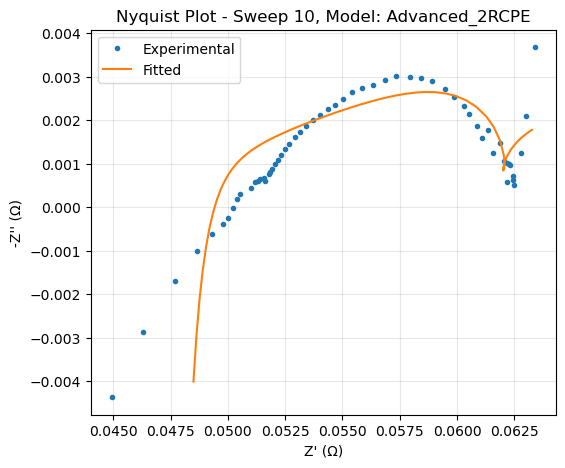

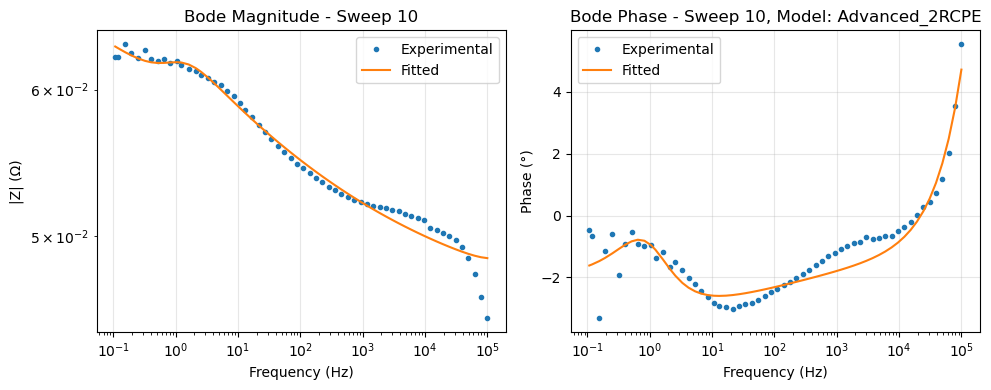


Merged features shape: (74, 793)
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Random Forest best params: {'regressor__max_depth': 10, 'regressor__n_estimators': 500}
Test RMSE (Parameters): 743831.3181

Predicted ECM Parameters for the entire dataset (rows = samples, columns = parameters):
[[7.94248166e-09 4.02788343e-02 8.08313603e-02 6.19821884e-02
  2.61698939e-03 3.72024675e+01 1.23845296e-01 1.05503072e+00
  5.68339384e+05 4.69283440e-01]
 [7.44594491e-09 3.98970214e-02 1.00985283e-01 6.09523704e-02
  1.67320731e-03 3.71401444e+01 1.00551440e-01 1.30702912e+00
  2.34358644e+05 2.77297694e-01]
 [6.87991921e-09 3.52794587e-02 4.49852482e-02 1.84168090e-01
  1.12798690e-02 4.51462281e+01 1.32985634e-01 1.33756598e+00
  2.51717491e+05 8.07737256e-01]
 [7.59972883e-09 3.72631739e-02 6.18738792e-02 1.31493909e-01
  7.50695206e-03 4.19479318e+01 1.28354457e-01 1.18876222e+00
  4.10342880e+05 7.33053287e-01]
 [7.53674700e-09 3.84005109e-02 6.38266380e-02 1.15975867e-01
  

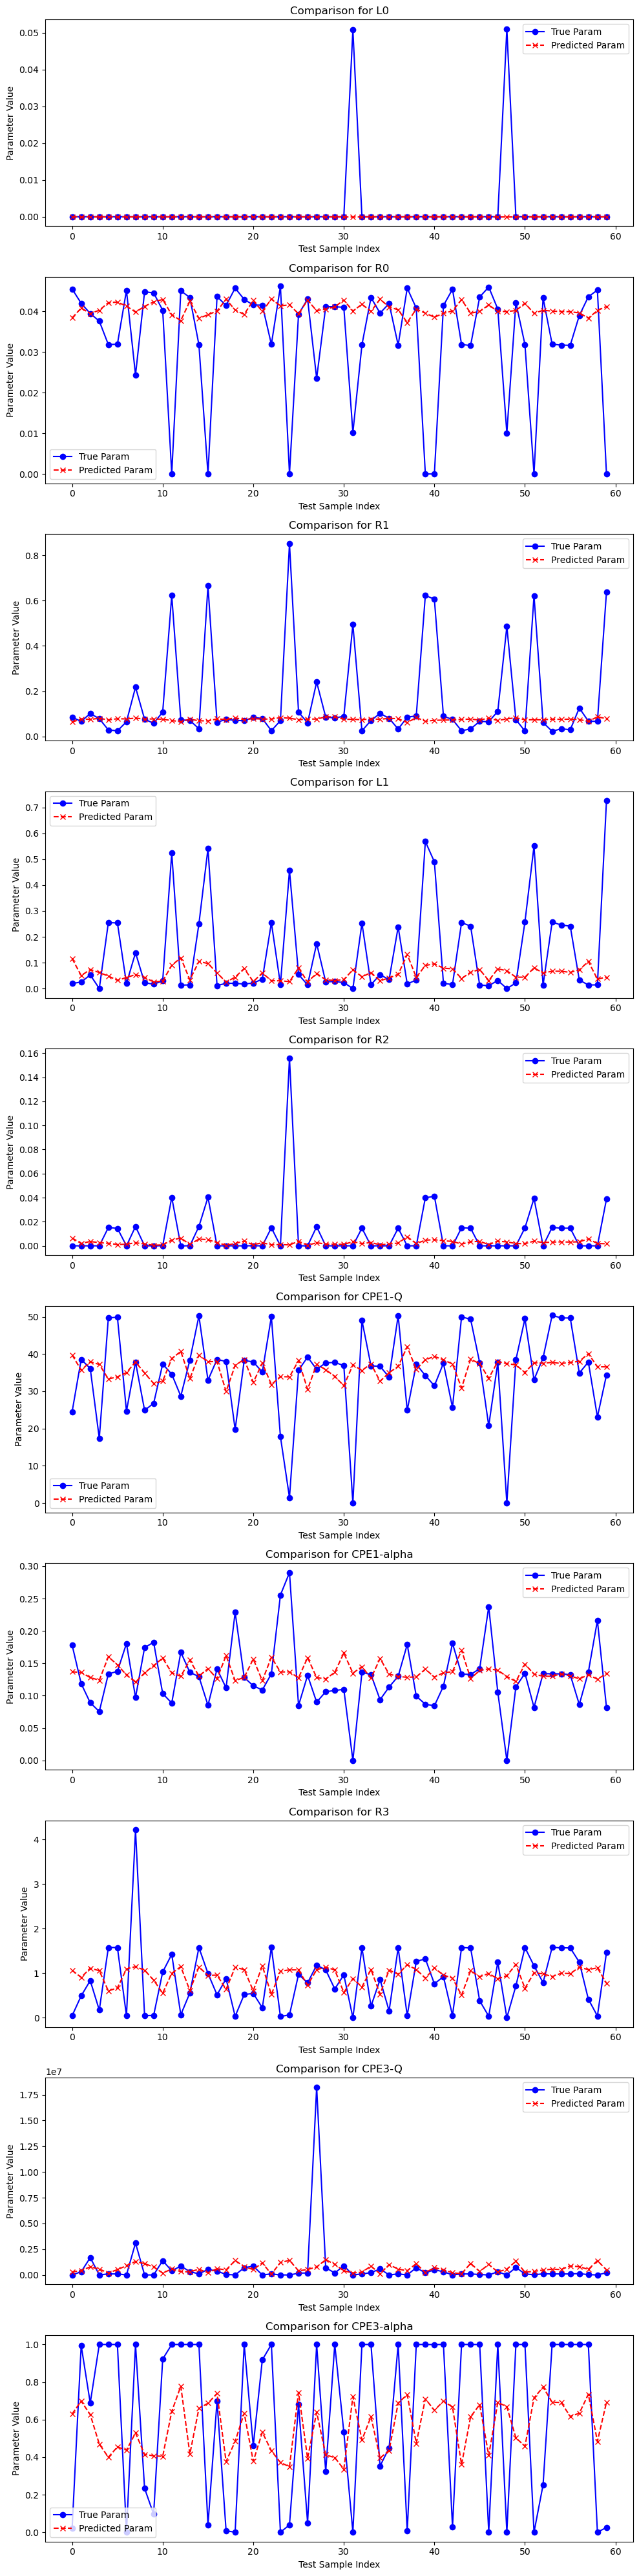

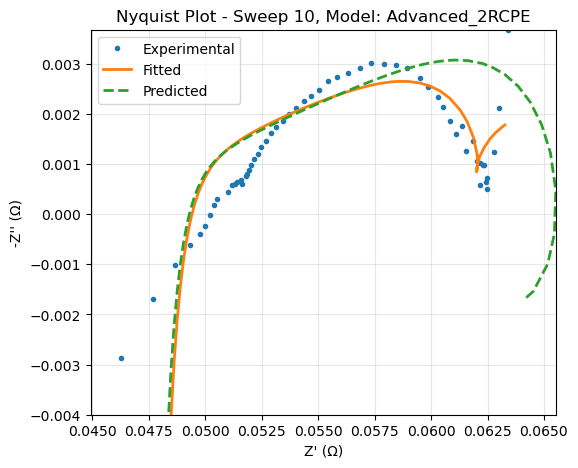

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from pathlib import Path

from impedance.models.circuits import CustomCircuit
from impedance import preprocessing

from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb  # still imported if needed later

warnings.filterwarnings("ignore")

###############################################################################
# 1. DATA LOADING: MULTI-SHEET EXCEL (6300.xls)
###############################################################################
file_path = "6300.xls"  # Path to your Excel file
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Prefer the "Probe Frequency Domain" sheet if available
if "Probe Frequency Domain" in all_sheets and not all_sheets["Probe Frequency Domain"].empty:
    df_eis = all_sheets["Probe Frequency Domain"]
    print("Using sheet: 'Probe Frequency Domain'")
elif "EIS_Data" in all_sheets and not all_sheets["EIS_Data"].empty:
    df_eis = all_sheets["EIS_Data"]
    print("Using sheet: 'EIS_Data'")
else:
    for sheet_name, sheet_df in all_sheets.items():
        if not sheet_df.empty:
            df_eis = sheet_df
            print(f"Using sheet: '{sheet_name}' (fallback)")
            break
    else:
        raise ValueError("No nonempty sheet found in 6300.xls.")

df_fitted_params = all_sheets.get("Fitted_Parameters", pd.DataFrame())

###############################################################################
# 2. DATA CLEANUP & TIME DERIVATION
###############################################################################
print("Available columns before renaming:", df_eis.columns.tolist())
rename_map = {
    "Frequency (Hz)": "frequency",
    "Real Impedance Re{z}(Ω)": "Z_real",
    "Negative Imaginary Impedance -Im{z}(Ω)": "Z_imag_neg",
    "Time": "time"
}
df_eis.rename(columns=rename_map, inplace=True)
print("Available columns after renaming:", df_eis.columns.tolist())

required_cols = ["frequency", "Z_real", "Z_imag_neg"]
missing = [col for col in required_cols if col not in df_eis.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}. Available columns: {df_eis.columns.tolist()}")
df_eis.dropna(subset=required_cols, inplace=True)
if "time" in df_eis.columns:
    df_eis["time"] = pd.to_datetime(df_eis["time"], errors="coerce")
    df_eis.dropna(subset=["time"], inplace=True)
    df_eis["RelTime_sec"] = (df_eis["time"] - df_eis["time"].min()).dt.total_seconds()
    df_eis["RelTime_hr"] = df_eis["RelTime_sec"] / 3600
else:
    df_eis["RelTime_hr"] = np.arange(len(df_eis)) * 0.1
df_eis["sweep_id"] = df_eis.groupby("time").ngroup() if "time" in df_eis.columns else 0

###############################################################################
# 3. AUTO-FEATURIZATION WITH TSFRESH
###############################################################################
df_tsfresh = df_eis[["sweep_id", "frequency", "Z_real"]].rename(
    columns={"sweep_id": "id", "frequency": "time", "Z_real": "value"}
)
extracted_features = extract_features(df_tsfresh, column_id="id", column_sort="time", n_jobs=0)
extracted_features = impute(extracted_features)
extracted_features.reset_index(inplace=True)
extracted_features.rename(columns={"index": "sweep_id"}, inplace=True)
extracted_features.to_excel("ecm_features.xlsx", index=False)
print("TSFRESH features saved to 'ecm_features.xlsx'.")

###############################################################################
# 4. DEFINE ECM MODELS WITH INITIAL GUESSES
###############################################################################
simple_model_info = {
    "name": "Simple_Randles",
    "circuit": "R0-p(R1,C1)",
    "initial_guess": [0.04911, 0.0086883, 0.45421],
    "param_names": ["R0", "R1", "C1"]
}
advanced_model_info = {
    "name": "Advanced_2RCPE",
    "circuit": "L0-R0-p(R1-L1, R2-CPE1, R3-CPE3)",
    "initial_guess": [
        0.0,       # L0
        0.04941,   # R0
        0.0083883, # R1
        2.0785,    # L1
        0.0083683, # R2
        0.46421,   # CPE1-Q
        1.0,       # CPE1-alpha
        2.2071,    # R3
        1.0,       # CPE3-Q
        1.0        # CPE3-alpha
    ],
    "param_names": ["L0", "R0", "R1", "L1", "R2", "CPE1-Q", "CPE1-alpha", "R3", "CPE3-Q", "CPE3-alpha"]
}
model_candidates = [simple_model_info, advanced_model_info]

###############################################################################
# 5. ECM FITTING FUNCTION
###############################################################################
def fit_and_evaluate_model(model_dict, freq, Z_exp):
    circuit_str = model_dict["circuit"]
    init_guess = model_dict["initial_guess"]
    circuit_model = CustomCircuit(circuit=circuit_str, initial_guess=init_guess)
    circuit_model.fit(freq, Z_exp)
    Z_fit = circuit_model.predict(freq)
    residuals = Z_exp - Z_fit
    rmse = np.sqrt(np.mean(np.abs(residuals)**2))
    n = len(freq)
    k = len(circuit_model.parameters_)
    rss = np.sum(np.abs(residuals)**2)
    N_eff = 2 * n
    aic = 2 * k + N_eff * np.log(rss / N_eff + 1e-15)
    bic = np.log(N_eff) * k + N_eff * np.log(rss / N_eff + 1e-15)
    param_names = model_dict["param_names"]
    fitted_params = circuit_model.parameters_
    for name, value in zip(param_names, fitted_params):
        if (name.startswith('R') or name.startswith('L')) and value < 0:
            return None
    return {
        "model_name": model_dict["name"],
        "params": fitted_params,
        "param_names": param_names,
        "rmse": rmse,
        "aic": aic,
        "bic": bic
    }

###############################################################################
# 6. LOOP OVER SWEEPS AND SELECT THE BEST MODEL PER SWEEP
###############################################################################
error_threshold_percent = 10.0
fit_results = []
for sweep_id, group in df_eis.groupby("sweep_id"):
    group = group.sort_values("frequency")
    if len(group) < 3:
        continue
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    if not np.all(np.isfinite(Z_exp)) or np.any(freq <= 0):
        continue
    best_fit = None
    for model_dict in model_candidates:
        try:
            result = fit_and_evaluate_model(model_dict, freq, Z_exp)
            if result is None:
                continue
            avg_imp = np.mean(np.abs(Z_exp))
            rel_error_percent = (result["rmse"] / avg_imp) * 100
            if rel_error_percent <= error_threshold_percent:
                if best_fit is None or (result["rmse"] < best_fit["rmse"] or result["aic"] < best_fit["aic"]):
                    best_fit = result
                    best_fit["rel_error_percent"] = rel_error_percent
        except Exception as e:
            print(f"Fitting failed for sweep {sweep_id} with model {model_dict['name']}: {e}")
    if best_fit is not None:
        time_val = group["time"].iloc[0] if "time" in group.columns else None
        rel_time_hr = group["RelTime_hr"].iloc[0] if "RelTime_hr" in group.columns else None
        fit_results.append({
            "sweep_id": sweep_id,
            "time": time_val,
            "RelTime_hr": rel_time_hr,
            "model_name": best_fit["model_name"],
            "RMSE": best_fit["rmse"],
            "AIC": best_fit["aic"],
            "BIC": best_fit["bic"],
            "rel_error_percent": best_fit["rel_error_percent"],
            "param_names": best_fit["param_names"],
            "params": best_fit["params"]
        })
fit_df = pd.DataFrame(fit_results)
if "RelTime_hr" in fit_df.columns and fit_df["RelTime_hr"].notnull().all():
    fit_df = fit_df.sort_values("RelTime_hr")
else:
    fit_df = fit_df.sort_values("sweep_id")
if fit_df.empty:
    raise RuntimeError("No valid ECM fits found for any sweep.")
fit_df.to_excel("ECM_fitting_results_advanced.xlsx", index=False)
print("Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'")
print(fit_df.head())

###############################################################################
# 7. VALIDATION PLOTS: NYQUIST AND BODE PLOTS FOR BEST FIT
###############################################################################
def plot_nyquist(freq, Z_exp, Z_fit, sweep_id, model_name):
    plt.figure(figsize=(6, 5))
    plt.plot(Z_exp.real, -Z_exp.imag, 'o', label='Experimental', markersize=3)
    plt.plot(Z_fit.real, -Z_fit.imag, '-', label='Fitted')
    plt.xlabel("Z' (Ω)")
    plt.ylabel("-Z'' (Ω)")
    plt.title(f'Nyquist Plot - Sweep {sweep_id}, Model: {model_name}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_bode(freq, Z_exp, Z_fit, sweep_id, model_name):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.loglog(freq, np.abs(Z_exp), 'o', label='Experimental', markersize=3)
    plt.loglog(freq, np.abs(Z_fit), '-', label='Fitted')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("|Z| (Ω)")
    plt.title(f'Bode Magnitude - Sweep {sweep_id}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.semilogx(freq, np.angle(Z_exp, deg=True), 'o', label='Experimental', markersize=3)
    plt.semilogx(freq, np.angle(Z_fit, deg=True), '-', label='Fitted')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Phase (°)")
    plt.title(f'Bode Phase - Sweep {sweep_id}, Model: {model_name}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

best_idx = fit_df["RMSE"].idxmin()
best_sweep_id = fit_df.loc[best_idx, "sweep_id"]
best_model_name = fit_df.loc[best_idx, "model_name"]
best_params = fit_df.loc[best_idx, "params"]
print(f"\nBest overall fit: Sweep {best_sweep_id}, Model: {best_model_name}")

# Retrieve candidate parameter names from best candidate dictionary.
best_param_names = None
for m in model_candidates:
    if m["name"] == best_model_name:
        best_param_names = m["param_names"]
        best_circuit = CustomCircuit(circuit=m["circuit"], initial_guess=m["initial_guess"])
        best_circuit.parameters_ = best_params
        break

best_group = df_eis[df_eis["sweep_id"] == best_sweep_id].sort_values("frequency")
freq_best = best_group["frequency"].values
Z_exp_best = best_group["Z_real"].values + 1j * (-best_group["Z_imag_neg"].values)
Z_fit_best = best_circuit.predict(freq_best)
plot_nyquist(freq_best, Z_exp_best, Z_fit_best, best_sweep_id, best_model_name)
plot_bode(freq_best, Z_exp_best, Z_fit_best, best_sweep_id, best_model_name)

###############################################################################
# 8. MERGE TSFRESH FEATURES WITH FITTED LABELS FOR ML TRAINING
###############################################################################
merged_df = pd.merge(extracted_features, fit_df, on="sweep_id", how="inner").dropna()
print(f"\nMerged features shape: {merged_df.shape}")
X = merged_df.drop(columns=["sweep_id", "time", "model_name", "RMSE", "AIC", "BIC", 
                              "rel_error_percent", "param_names", "params", "RelTime_hr"], errors="ignore")
# Ensure all features are numeric and drop non-numeric columns
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=1)
X = X.values
param_list = merged_df["params"].tolist()
max_len = max(len(p) for p in param_list)
Y = np.array([np.pad(p, (0, max_len - len(p)), constant_values=np.nan) for p in param_list])
Y = np.nan_to_num(Y)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.8, random_state=42)

###############################################################################
# 9. TRAIN ML MODEL USING RANDOM FOREST (with hyperparameter tuning)
###############################################################################
from sklearn.ensemble import RandomForestRegressor
pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", RandomForestRegressor(random_state=42))
])
param_grid_rf = {
    "regressor__n_estimators": [100, 300, 500],
    "regressor__max_depth": [5, 10, 20]
}
grid_search_rf = GridSearchCV(
    pipeline_rf, param_grid_rf, scoring="neg_mean_squared_error", cv=3, verbose=1, n_jobs=-1
)
grid_search_rf.fit(X_train, y_train)
best_model = grid_search_rf.best_estimator_
y_pred = best_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nRandom Forest best params: {grid_search_rf.best_params_}")
print(f"Test RMSE (Parameters): {rmse_test:.4f}")

###############################################################################
# 10. PRINT PREDICTED VALUES FOR THE ENTIRE DATASET
###############################################################################
predicted_all = best_model.predict(X)
print("\nPredicted ECM Parameters for the entire dataset (rows = samples, columns = parameters):")
print(predicted_all)
merged_df["predicted_params"] = list(predicted_all)

###############################################################################
# 11. COMPARISON PLOTS: TRUE VS. PREDICTED ECM PARAMETERS
###############################################################################
n_params = Y.shape[1]
fig, axs = plt.subplots(n_params, 1, figsize=(10, 4 * n_params))
if n_params == 1:
    axs = [axs]
for i in range(n_params):
    sample_indices = np.arange(len(y_test[:, i]))
    axs[i].plot(sample_indices, y_test[:, i], 'bo-', label='True Param')
    axs[i].plot(sample_indices, y_pred[:, i], 'rx--', label='Predicted Param')
    axs[i].set_xlabel("Test Sample Index")
    axs[i].set_ylabel("Parameter Value")
    param_label = (merged_df['param_names'].iloc[0][i]
                   if 'param_names' in merged_df.columns and isinstance(merged_df['param_names'].iloc[0], (list, tuple))
                   else f"Parameter {i}")
    axs[i].set_title(f"Comparison for {param_label}")
    axs[i].legend()
plt.tight_layout()
plt.show()

###############################################################################
# 12. TRIPLE NYQUIST PLOT: EXPERIMENTAL, FITTED, AND PREDICTED
###############################################################################
def plot_nyquist_three(freq, Z_exp, Z_fit, Z_pred, sweep_id, model_name):
    plt.figure(figsize=(6, 5))
    plt.plot(Z_exp.real, -Z_exp.imag, 'o', label='Experimental', markersize=3)
    if Z_fit is not None:
        plt.plot(Z_fit.real, -Z_fit.imag, '-', label='Fitted', linewidth=2)
    if Z_pred is not None:
        plt.plot(Z_pred.real, -Z_pred.imag, '--', label='Predicted', linewidth=2)
    # Set axis limits: force y-axis lower limit to -0.004
    x_min = min(np.min(Z_exp.real), np.min(Z_fit.real) if Z_fit is not None else np.inf, 
                np.min(Z_pred.real) if Z_pred is not None else np.inf)
    x_max = max(np.max(Z_exp.real), np.max(Z_fit.real) if Z_fit is not None else -np.inf, 
                np.max(Z_pred.real) if Z_pred is not None else -np.inf)
    y_max = max(np.max(-Z_exp.imag), np.max(-Z_fit.imag) if Z_fit is not None else -np.inf, 
                np.max(-Z_pred.imag) if Z_pred is not None else -np.inf)
    y_min = -0.004
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel("Z' (Ω)")
    plt.ylabel("-Z'' (Ω)")
    plt.title(f'Nyquist Plot - Sweep {sweep_id}, Model: {model_name}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def get_fitted_and_predicted_impedance(sweep_id, fit_df, merged_df, best_model, df_eis, fallback_circuit):
    group = df_eis[df_eis["sweep_id"] == sweep_id].sort_values("frequency")
    if group.empty:
        print(f"No data found for sweep {sweep_id}.")
        return None, None, None, None, None
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    row = fit_df[fit_df["sweep_id"] == sweep_id]
    if row.empty:
        print(f"No fitted ECM found for sweep {sweep_id}.")
        return freq, Z_exp, None, None, None
    fitted_params = row.iloc[0]["params"]
    model_name = row.iloc[0]["model_name"]
    circuit_fit = CustomCircuit(circuit=fallback_circuit.circuit, initial_guess=fallback_circuit.initial_guess)
    circuit_fit.parameters_ = fitted_params
    Z_fit = circuit_fit.predict(freq)
    features_sweep = merged_df[merged_df["sweep_id"] == sweep_id]
    if features_sweep.empty:
        print(f"No TSFRESH features found for sweep {sweep_id}. Cannot predict.")
        return freq, Z_exp, Z_fit, None, model_name
    features_sweep_agg = features_sweep.groupby("sweep_id").mean(numeric_only=True).reset_index()
    drop_cols = ["sweep_id", "time", "model_name", "RMSE", "AIC", "BIC",
                 "rel_error_percent", "param_names", "params", "RelTime_hr"]
    features_sweep_agg = features_sweep_agg.drop(columns=drop_cols, errors="ignore")
    features_sweep_agg = features_sweep_agg.select_dtypes(include=[np.number])
    X_sweep = features_sweep_agg.values
    if X_sweep.shape[0] > 1:
        X_sweep = X_sweep.mean(axis=0, keepdims=True)
    predicted_params = best_model.predict(X_sweep)[0]
    circuit_pred = CustomCircuit(circuit=fallback_circuit.circuit, initial_guess=fallback_circuit.initial_guess)
    circuit_pred.parameters_ = predicted_params
    Z_pred = circuit_pred.predict(freq)
    return freq, Z_exp, Z_fit, Z_pred, model_name

sweep_to_plot = 10
freq_sweep, Z_exp_sweep, Z_fit_sweep, Z_pred_sweep, model_name = get_fitted_and_predicted_impedance(
    sweep_id=sweep_to_plot,
    fit_df=fit_df,
    merged_df=merged_df,
    best_model=best_model,
    df_eis=df_eis,
    fallback_circuit=best_circuit
)
if freq_sweep is not None:
    plot_nyquist_three(freq_sweep, Z_exp_sweep, Z_fit_sweep, Z_pred_sweep, sweep_to_plot, model_name)